In [ ]:
# @title
# Check GPU
import torch, sys
print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
  print("GPU:", torch.cuda.get_device_name(0))

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch version: 2.9.0+cu126
CUDA available: False


In [ ]:
# Install dependencies
!pip install -q kaggle
!pip install -q tqdm


In [ ]:
import os, shutil

# Make Kaggle config dir and move kaggle.json
'''
os.makedirs("/root/.kaggle", exist_ok=True)
if not os.path.exists("/root/.kaggle/kaggle.json"):
    from google.colab import files
    uploaded = files.upload()  # upload kaggle.json here
    shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 0o600)

# Download dataset
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri -p /content
'''
# Unzip
!unzip -q /content/archive.zip -d /content/brain_tumor_raw
!ls /content/brain_tumor_raw


Testing  Training


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Step 3 – Prepare data (split train/val, define loaders)
import os
import random
from pathlib import Path

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler

DATA_ROOT = "/content/brain_tumor_raw"
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR = os.path.join(DATA_ROOT, "Testing")

print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes:", os.listdir(TEST_DIR))


Train classes: ['meningioma_tumor', 'pituitary_tumor', 'no_tumor', 'glioma_tumor']
Test classes: ['meningioma_tumor', 'pituitary_tumor', 'no_tumor', 'glioma_tumor']


In [ ]:
'''
from sklearn.model_selection import StratifiedShuffleSplit
from torchvision.datasets import ImageFolder

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

# Full training dataset
full_train_ds = ImageFolder(TRAIN_DIR, transform=train_transform)

targets = full_train_ds.targets
indices = list(range(len(full_train_ds)))

# Stratified split train/val: 80/20
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(indices, targets))

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE,
                          sampler=train_sampler, num_workers=NUM_WORKERS)

val_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE,
                        sampler=val_sampler, num_workers=NUM_WORKERS)

# Test dataset from Testing folder
test_ds = ImageFolder(TEST_DIR, transform=eval_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS)

class_names = full_train_ds.classes
print("Classes:", class_names)
print("Train size:", len(train_idx), "Val size:", len(val_idx), "Test size:", len(test_ds))
'''

Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Train size: 2296 Val size: 574 Test size: 394


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit
import os

DATA_ROOT = "/content/brain_tumor_raw"
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR  = os.path.join(DATA_ROOT, "Testing")

print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes:", os.listdir(TEST_DIR))

# -----------------------------
# Preprocessing & Augmentation
# -----------------------------
# This block corresponds to your write-up:
# • Skull-stripping (assumed pre-done in Kaggle slices)
# • Intensity normalization
# • Resizing to 224×224
# • Channel expansion (1 → 3 channels)
# • Data augmentation (flips, rotations, contrast/brightness jitter)

def intensity_normalize(t):
    # t: (C, H, W), typically single-channel after ToTensor
    mean = t.mean()
    std  = t.std()
    return (t - mean) / (std + 1e-8)

def expand_to_3ch(t):
    # If single-channel, expand to 3 channels
    if t.shape[0] == 1:
        return t.expand(3, -1, -1)
    return t

# Training transform: resize, augmentation, tensor, normalization, channel expansion
train_transform = transforms.Compose([
    # Resizing (ResNet input size)
    transforms.Resize((224, 224)),

    # Data augmentation (applied on PIL images)
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # To tensor
    transforms.ToTensor(),

    # Intensity normalization (per-slice z-score)
    transforms.Lambda(intensity_normalize),

    # Channel expansion to 3 channels
    transforms.Lambda(expand_to_3ch),
])

# Validation / test transform: no heavy augmentation, only basic geometric + normalization
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(intensity_normalize),
    transforms.Lambda(expand_to_3ch),
])

# -----------------------------
# Train / Val Split
# -----------------------------
full_train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
targets = full_train_ds.targets
indices = list(range(len(full_train_ds)))

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(indices, targets))

train_sampler = SubsetRandomSampler(train_idx)
val_sampler   = SubsetRandomSampler(val_idx)

BATCH_SIZE   = 32
NUM_WORKERS  = 2

train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE,
                          sampler=train_sampler, num_workers=NUM_WORKERS)

# For validation, we want the eval transform, not the train transform
# Easiest: create a second dataset pointing to the same folder but with eval_transform
val_ds = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE,
                        sampler=val_sampler, num_workers=NUM_WORKERS)

# -----------------------------
# Test loader
# -----------------------------
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS)

class_names = full_train_ds.classes
print("Classes:", class_names)
print("Train size:", len(train_idx), "Val size:", len(val_idx), "Test size:", len(test_ds))


Train classes: ['meningioma_tumor', 'pituitary_tumor', 'no_tumor', 'glioma_tumor']
Test classes: ['meningioma_tumor', 'pituitary_tumor', 'no_tumor', 'glioma_tumor']
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Train size: 2296 Val size: 574 Test size: 394


In [ ]:
#Step 4 – Define model (ResNet-50) + training functions
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

def build_resnet50(num_classes: int):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    in_feats = model.fc.in_features
    model.fc = nn.Linear(in_feats, num_classes)
    return model

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    return avg_loss, acc

@torch.no_grad()
def evaluate(model, loader, desc="Val"):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in tqdm(loader, desc=desc, leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    return avg_loss, acc


Using device: cuda


In [ ]:
NUM_EPOCHS = 7
LR = 1e-4

model = build_resnet50(num_classes=len(class_names)).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val_acc = 0.0
best_path = "/content/resnet50_brain_tumor.pth"
patience = 5
patience_counter = 0

for epoch in range(1, NUM_EPOCHS+1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, desc="Val")

    print(f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f}")
    print(f"Val   loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)
        print(f"New best model saved (val acc={best_val_acc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

print("\nLoading best model for test evaluation...")
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
test_loss, test_acc = evaluate(model, test_loader, desc="Test")
print(f"Test loss: {test_loss:.4f}, acc: {test_acc:.4f}")



Epoch 1/7


Train:   0%|          | 0/72 [00:00<?, ?it/s]

Val:   0%|          | 0/18 [00:00<?, ?it/s]

Train loss: 0.3884, acc: 0.8598
Val   loss: 0.2778, acc: 0.8972
New best model saved (val acc=0.8972)

Epoch 2/7


Train:   0%|          | 0/72 [00:00<?, ?it/s]

...

Train:   0%|          | 0/72 [00:00<?, ?it/s]

Val:   0%|          | 0/18 [00:00<?, ?it/s]

Train loss: 0.0613, acc: 0.9808
Val   loss: 0.1155, acc: 0.9652

Loading best model for test evaluation...


Test:   0%|          | 0/13 [00:00<?, ?it/s]

Test loss: 1.3000, acc: 0.7817


In [ ]:
#Step 5 – Filter extraction (3×3 conv filters)
import numpy as np

def extract_3x3_filters(model: nn.Module):
    layer_filters = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) and module.kernel_size == (3, 3):
            w = module.weight.detach().cpu().numpy()   # (Cout, Cin, 3, 3)
            cout, cin, kh, kw = w.shape
            f = w.reshape(cout * cin, -1)              # (Cout*Cin, 9)
            layer_filters[name] = f
    return layer_filters

model.eval()
layer_filters = extract_3x3_filters(model)
print("Number of 3x3 conv layers:", len(layer_filters))
for k, v in list(layer_filters.items())[:5]:
    print(k, v.shape)


Number of 3x3 conv layers: 16
layer1.0.conv2 (4096, 9)
layer1.1.conv2 (4096, 9)
layer1.2.conv2 (4096, 9)
layer2.0.conv2 (16384, 9)
layer2.1.conv2 (16384, 9)


In [ ]:
#Step 6 – CNN Filter DB–style analysis (PCA, entropy, sparsity, KL drift)
from numpy.linalg import svd

SPARSITY_EPS = 1e-5
KL_EPS = 1e-8
NUM_BINS = 70

def compute_svd_pca(filters: np.ndarray):
    # filters: (N, 9)
    X = filters - filters.mean(axis=0, keepdims=True)
    N = X.shape[0]
    U, S, Vt = svd(X, full_matrices=False)
    a = (S**2) / (N - 1)           # variance per component
    a_hat = a / a.sum()            # explained variance ratio
    return U, S, Vt, a_hat

def compute_entropy(a_hat: np.ndarray):
    p = np.clip(a_hat, 1e-12, 1.0)
    return float(-(p * np.log10(p)).sum())

def compute_sparsity(filters: np.ndarray, eps=SPARSITY_EPS):
    near_zero = np.all((filters >= -eps) & (filters <= eps), axis=1)
    return float(near_zero.mean())

def compute_kl_symmetric(p: np.ndarray, q: np.ndarray):
    p = np.clip(p, KL_EPS, None)
    q = np.clip(q, KL_EPS, None)
    p = p / p.sum()
    q = q / q.sum()
    kl_pq = np.sum(p * np.log(p / q))
    kl_qp = np.sum(q * np.log(q / p))
    return float(kl_pq + kl_qp)

def compute_distribution_shift(filters_A: np.ndarray,
                               filters_B: np.ndarray,
                               num_bins: int = NUM_BINS):
    # Combine for joint PCA
    combined = np.vstack([filters_A, filters_B])
    Xc = combined - combined.mean(axis=0, keepdims=True)
    U, S, Vt = svd(Xc, full_matrices=False)
    N = Xc.shape[0]
    a = (S**2) / (N - 1)
    a_hat = a / a.sum()

    C = U * S  # PCA coefficients
    nA = filters_A.shape[0]
    C_A = C[:nA, :]
    C_B = C[nA:, :]

    total_shift = 0.0
    for i in range(C_A.shape[1]):
        coeff_A = C_A[:, i]
        coeff_B = C_B[:, i]
        min_val = min(coeff_A.min(), coeff_B.min())
        max_val = max(coeff_A.max(), coeff_B.max())
        if min_val == max_val:
            continue
        bins = np.linspace(min_val, max_val, num_bins+1)
        hist_A, _ = np.histogram(coeff_A, bins=bins, density=True)
        hist_B, _ = np.histogram(coeff_B, bins=bins, density=True)

        hist_A = np.clip(hist_A, KL_EPS, None)
        hist_B = np.clip(hist_B, KL_EPS, None)
        hist_A = hist_A / hist_A.sum()
        hist_B = hist_B / hist_B.sum()

        kl_sym = compute_kl_symmetric(hist_A, hist_B)
        total_shift += a_hat[i] * kl_sym

    return float(total_shift)


In [ ]:
layer_stats = {}
for name, filt in layer_filters.items():
    if filt.shape[0] < 10:
        continue
    U, S, Vt, a_hat = compute_svd_pca(filt)
    H = compute_entropy(a_hat)
    S_layer = compute_sparsity(filt)
    layer_stats[name] = {
        "entropy": H,
        "sparsity": S_layer,
        "num_filters": int(filt.shape[0])
    }

len(layer_stats), list(layer_stats.items())[:3]


(16,
 [('layer1.0.conv2',
   {'entropy': 0.7923581004142761,
    'sparsity': 0.121337890625,
    'num_filters': 4096}),
  ('layer1.1.conv2',
   {'entropy': 0.8591874837875366, 'sparsity': 0.0625, 'num_filters': 4096}),
  ('layer1.2.conv2',
   {'entropy': 0.9080858826637268, 'sparsity': 0.0, 'num_filters': 4096})])

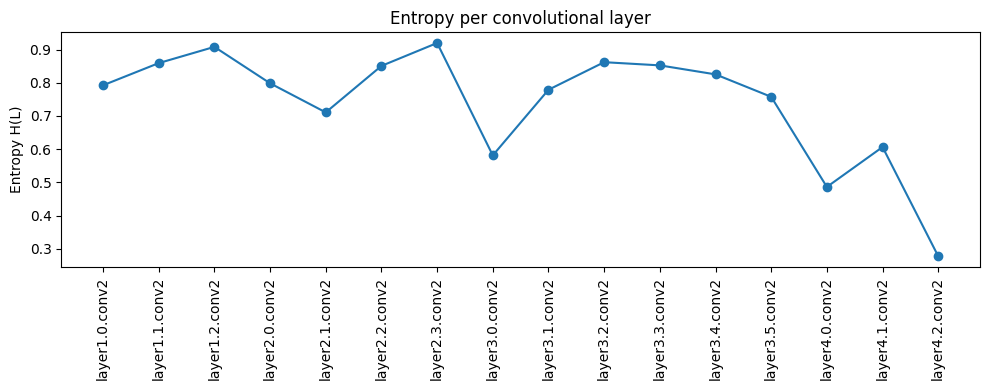

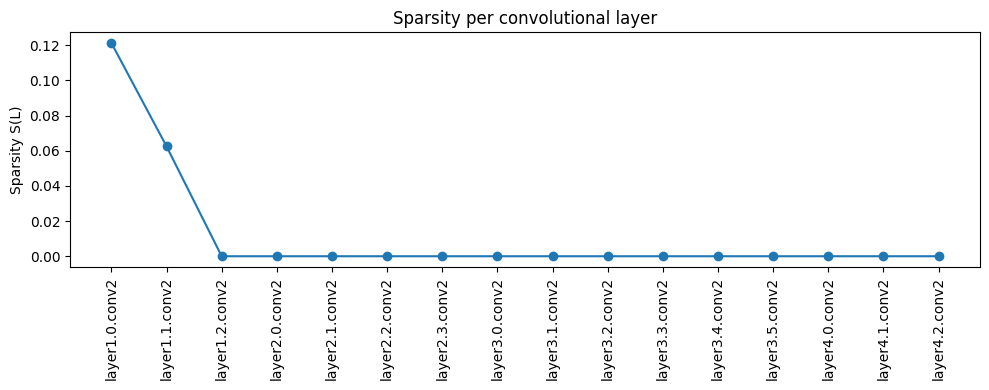

In [ ]:
#Step 7 – Plot entropy & sparsity across depth
import matplotlib.pyplot as plt

# Sort layers by name to keep order deterministic (not strictly real depth, but stable)
layer_names = sorted(layer_stats.keys())
entropies = [layer_stats[name]["entropy"] for name in layer_names]
sparsities = [layer_stats[name]["sparsity"] for name in layer_names]

x = np.arange(len(layer_names))

plt.figure(figsize=(10, 4))
plt.plot(x, entropies, marker='o')
plt.xticks(x, layer_names, rotation=90)
plt.ylabel("Entropy H(L)")
plt.title("Entropy per convolutional layer")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x, sparsities, marker='o')
plt.xticks(x, layer_names, rotation=90)
plt.ylabel("Sparsity S(L)")
plt.title("Sparsity per convolutional layer")
plt.tight_layout()
plt.show()


In [ ]:
#Step 8 – Example: KL-symmetric drift between first and last 3×3 layers
sorted_layer_names = sorted(layer_filters.keys())
if len(sorted_layer_names) >= 2:
    first_layer = sorted_layer_names[0]
    last_layer = sorted_layer_names[-1]
    D = compute_distribution_shift(layer_filters[first_layer],
                                   layer_filters[last_layer])
    print(f"KL-symmetric drift between '{first_layer}' and '{last_layer}': {D:.4f}")
else:
    print("Not enough 3x3 conv layers to compute distribution shift.")


KL-symmetric drift between 'layer1.0.conv2' and 'layer4.2.conv2': 0.7878


In [ ]:
#First 3×3 filters extracted from each convolution layer
import matplotlib.pyplot as plt
import numpy as np
import math
import os

os.makedirs("fig_filters", exist_ok=True)

def visualize_first_filters(weight_tensor, max_filters=16):
    """
    weight_tensor: (Cout, Cin, 3, 3)
    we visualize filters for Cin=0 only (first input channel),
    and first max_filters output channels.
    """
    cout, cin, kh, kw = weight_tensor.shape
    n = min(cout, max_filters)
    cols = 4
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    axes = axes.flatten()

    for i in range(len(axes)):
        ax = axes[i]
        ax.axis("off")
        if i < n:
            f = weight_tensor[i, 0, :, :]  # first input channel
            f_norm = (f - f.min()) / (f.max() - f.min() + 1e-8)
            ax.imshow(f_norm, cmap="gray")
        else:
            ax.imshow(np.zeros((3, 3)), cmap="gray")
    plt.tight_layout()
    return fig

# loop over conv layers
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Conv2d) and module.kernel_size == (3, 3):
        w = module.weight.detach().cpu().numpy()
        fig = visualize_first_filters(w, max_filters=16)
        fig.suptitle(f"First 3x3 filters - {name}", y=1.02)
        plt.tight_layout()
        fig.savefig(f"fig_filters/{name.replace('.', '_')}_first_filters.png",
                    bbox_inches="tight")
        plt.close(fig)

print("Saved filter visualization figures to fig_filters/")


Saved filter visualization figures to fig_filters/


In [ ]:
all_model_stats = {
    "resnet50": layer_stats
}

# Display the example structure
import json
print(json.dumps(all_model_stats, indent=2))

{
  "resnet50": {
    "layer1.0.conv2": {
      "entropy": 0.7923581004142761,
      "sparsity": 0.121337890625,
      "num_filters": 4096
    },
    "layer1.1.conv2": {
      "entropy": 0.8591874837875366,
      "sparsity": 0.0625,
      "num_filters": 4096
    },
    "layer1.2.conv2": {
      "entropy": 0.9080858826637268,
      "sparsity": 0.0,
      "num_filters": 4096
    },
    "layer2.0.conv2": {
      "entropy": 0.7983997464179993,
      "sparsity": 0.0,
      "num_filters": 16384
    },
    "layer2.1.conv2": {
      "entropy": 0.7106887698173523,
      "sparsity": 0.0,
      "num_filters": 16384
    },
    "layer2.2.conv2": {
      "entropy": 0.8507624268531799,
      "sparsity": 0.0,
      "num_filters": 16384
    },
    "layer2.3.conv2": {
      "entropy": 0.9197828769683838,
      "sparsity": 0.0,
      "num_filters": 16384
    },
    "layer3.0.conv2": {
      "entropy": 0.581194281578064,
      "sparsity": 0.0,
      "num_filters": 65536
    },
    "layer3.1.conv2": {
    

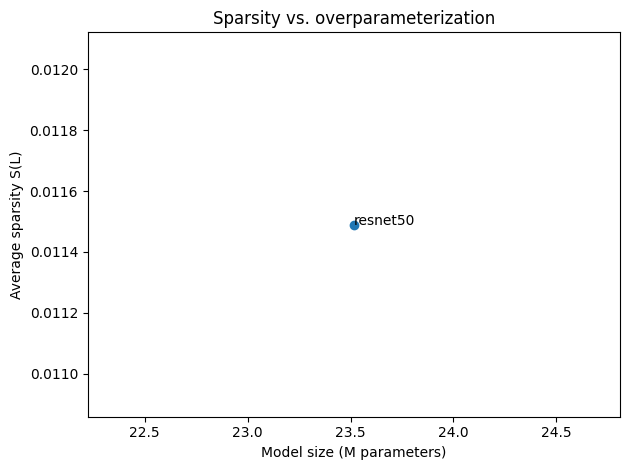

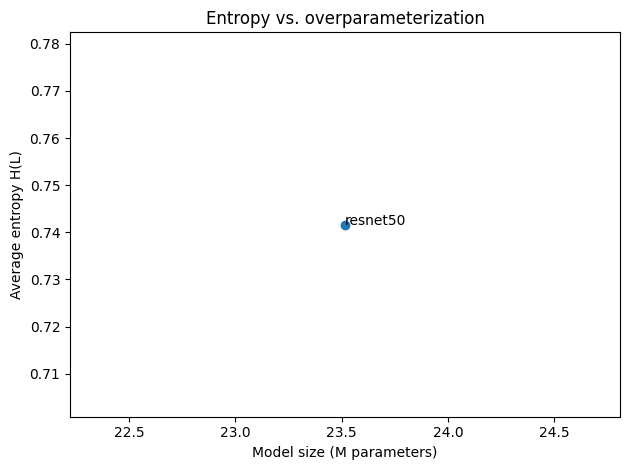

In [ ]:
#2. (a) Sparsity vs. overparameterization, (b) Entropy vs. overparameterization
import matplotlib.pyplot as plt

# Suppose you collected stats per model like:
# all_model_stats = {
#   "resnet18": layer_stats_18,
#   "resnet34": layer_stats_34,
#   "resnet50": layer_stats_50,
# }

# Initialize model_variants with the current 'model' for ResNet50
model_variants = {
    "resnet50": model
}

overparam_index = []
avg_sparsity = []
avg_entropy = []

for name, stats in all_model_stats.items():
    # crude overparameterization proxy: total params in millions
    m = sum(p.numel() for p in model_variants[name].parameters()) / 1e6
    overparam_index.append(m)

    S_vals = [d["sparsity"] for d in stats.values()]
    H_vals = [d["entropy"] for d in stats.values()]
    avg_sparsity.append(np.mean(S_vals))
    avg_entropy.append(np.mean(H_vals))

# (a) sparsity vs overparameterization
plt.figure()
plt.scatter(overparam_index, avg_sparsity)
for i, n in enumerate(all_model_stats.keys()):
    plt.text(overparam_index[i], avg_sparsity[i], n)
plt.xlabel("Model size (M parameters)")
plt.ylabel("Average sparsity S(L)")
plt.title("Sparsity vs. overparameterization")
plt.tight_layout()
plt.show()

# (b) entropy vs overparameterization
plt.figure()
plt.scatter(overparam_index, avg_entropy)
for i, n in enumerate(all_model_stats.keys()):
    plt.text(overparam_index[i], avg_entropy[i], n)
plt.xlabel("Model size (M parameters)")
plt.ylabel("Average entropy H(L)")
plt.title("Entropy vs. overparameterization")
plt.tight_layout()
plt.show()


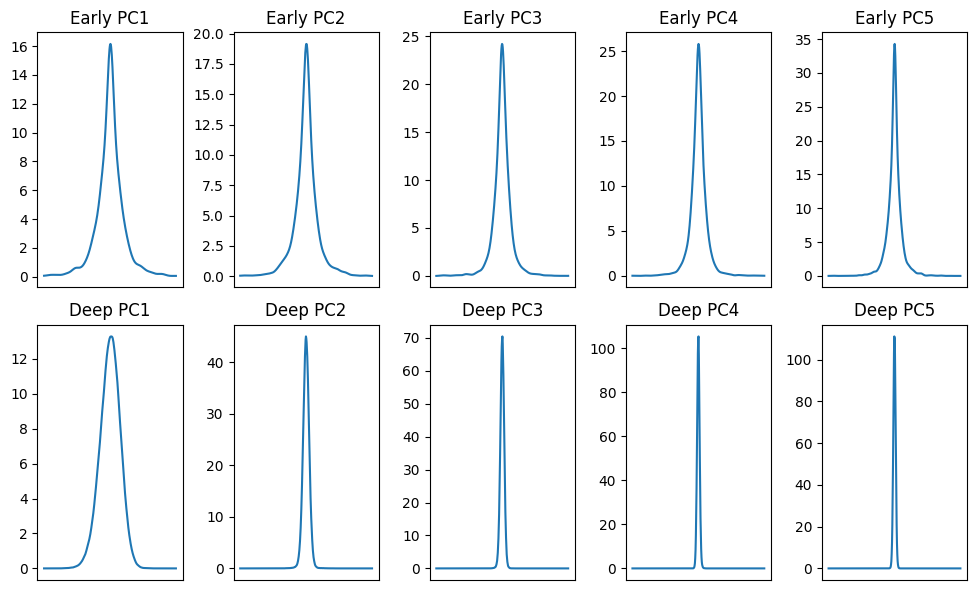

In [ ]:
#4. KDEs of coefficient distributions (Figure 3 style)
from scipy.stats import gaussian_kde

def pca_coefficients(filters):
    X = filters - filters.mean(axis=0, keepdims=True)
    U, S, Vt = svd(X, full_matrices=False)
    C = U * S   # coefficients
    return C

# Example: early vs deep layer comparison
early_layer = list(layer_filters.keys())[0]
deep_layer  = list(layer_filters.keys())[-1]

C_early = pca_coefficients(layer_filters[early_layer])
C_deep  = pca_coefficients(layer_filters[deep_layer])

num_components = min(5, C_early.shape[1])

x_grid = np.linspace(-0.2, 0.2, 400)

plt.figure(figsize=(10, 6))
for i in range(num_components):
    kde_e = gaussian_kde(C_early[:, i])
    kde_d = gaussian_kde(C_deep[:, i])
    plt.subplot(2, num_components, i+1)
    plt.plot(x_grid, kde_e(x_grid))
    plt.title(f"Early PC{i+1}")
    plt.xticks([])
    plt.subplot(2, num_components, num_components+i+1)
    plt.plot(x_grid, kde_d(x_grid))
    plt.title(f"Deep PC{i+1}")
    plt.xticks([])
plt.tight_layout()
plt.show()


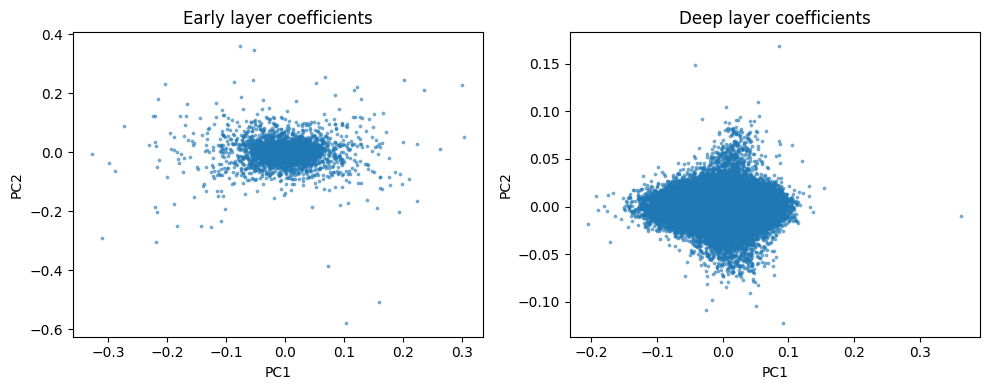

In [ ]:
#5. Bi-variate plots between components (Figure 4 style)
# bivariate scatter between PC1 and PC2 for early vs deep
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(C_early[:,0], C_early[:,1], s=3, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Early layer coefficients")

plt.subplot(1,2,2)
plt.scatter(C_deep[:,0], C_deep[:,1], s=3, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Deep layer coefficients")

plt.tight_layout()
plt.show()


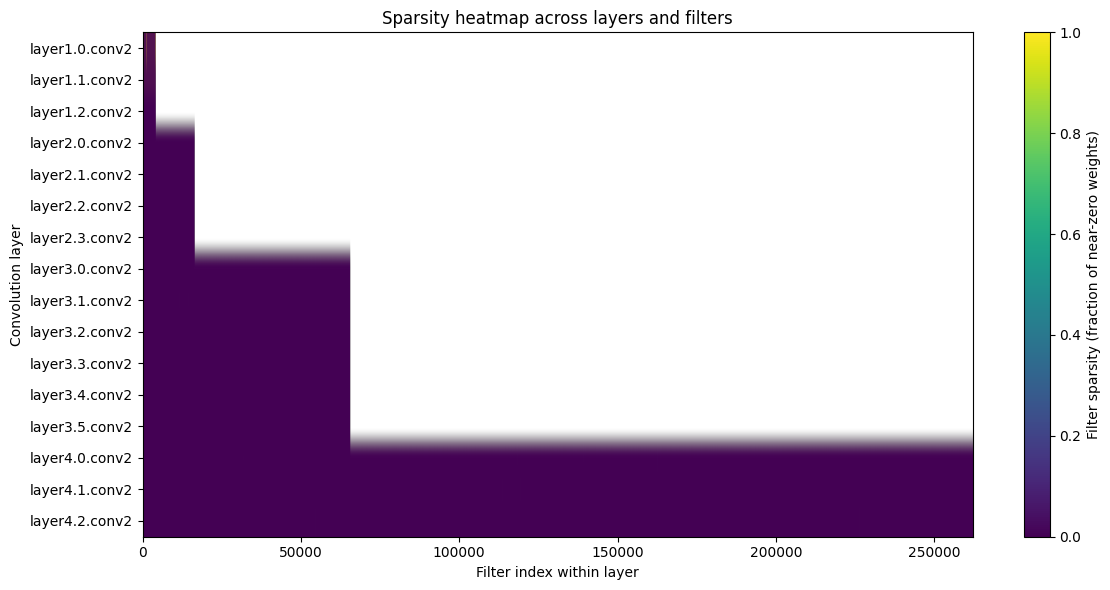

In [ ]:
#🔹 Sparsity Heatmap Code (Colab cell)
import numpy as np
import matplotlib.pyplot as plt

SPARSITY_EPS = 1e-5  # threshold for "near-zero"

# Sort layer names for a stable order (approx depth)
layer_names = sorted(layer_filters.keys())
num_layers = len(layer_names)
max_filters = max(f.shape[0] for f in layer_filters.values())

# heatmap matrix: rows = layers, cols = filter index
# we'll fill unused slots with NaN so they appear blank
heat = np.full((num_layers, max_filters), np.nan, dtype=np.float32)

for i, lname in enumerate(layer_names):
    f = layer_filters[lname]        # shape: (num_filters, 9)
    # sparsity per filter: fraction of weights near zero
    sparsity_per_filter = np.mean(np.abs(f) < SPARSITY_EPS, axis=1)  # in [0,1]
    n = len(sparsity_per_filter)
    heat[i, :n] = sparsity_per_filter

plt.figure(figsize=(12, 6))
im = plt.imshow(heat, aspect='auto', cmap='viridis', vmin=0, vmax=1)
cbar = plt.colorbar(im)
cbar.set_label("Filter sparsity (fraction of near-zero weights)")

plt.yticks(range(num_layers), layer_names)
plt.xlabel("Filter index within layer")
plt.ylabel("Convolution layer")
plt.title("Sparsity heatmap across layers and filters")
plt.tight_layout()
plt.show()


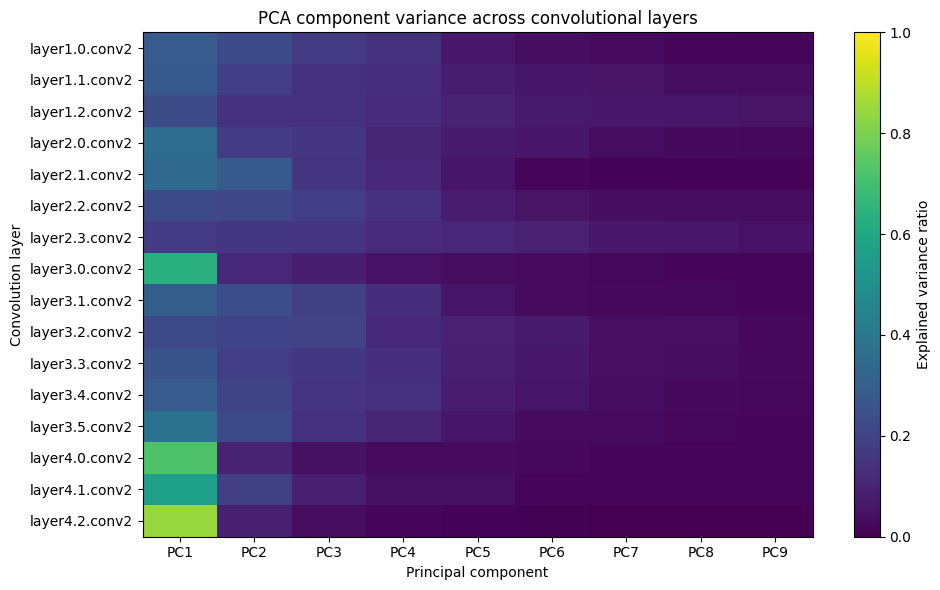

In [ ]:
#Per-layer PCA component variance heatmap

import numpy as np
import matplotlib.pyplot as plt

def pca_variance_ratios(filters: np.ndarray):
    """
    filters: (n_filters, 9)
    returns a_hat: (9,) explained variance ratios
    """
    X = filters - filters.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    N = X.shape[0]
    var = (S**2) / (N - 1)
    a_hat = var / var.sum()
    return a_hat

# Sort layer names for consistent y-axis order (approx depth order)
layer_names = sorted(layer_filters.keys())
num_layers = len(layer_names)
num_components = 9  # 3x3 filters -> at most 9 PCs

# Build matrix: rows = layers, cols = PCs
var_matrix = np.zeros((num_layers, num_components), dtype=np.float32)

for i, lname in enumerate(layer_names):
    f = layer_filters[lname]  # (n_filters, 9)
    if f.shape[0] < 10:
        # too few filters, skip or fill with NaNs
        var_matrix[i, :] = np.nan
        continue
    a_hat = pca_variance_ratios(f)
    # ensure length 9
    if len(a_hat) < num_components:
        a_hat = np.pad(a_hat, (0, num_components-len(a_hat)), constant_values=np.nan)
    var_matrix[i, :] = a_hat[:num_components]

plt.figure(figsize=(10, 6))
im = plt.imshow(var_matrix, aspect='auto', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(im, label="Explained variance ratio")

plt.yticks(range(num_layers), layer_names)
plt.xticks(range(num_components), [f"PC{i+1}" for i in range(num_components)])
plt.xlabel("Principal component")
plt.ylabel("Convolution layer")
plt.title("PCA component variance across convolutional layers")
plt.tight_layout()
plt.show()


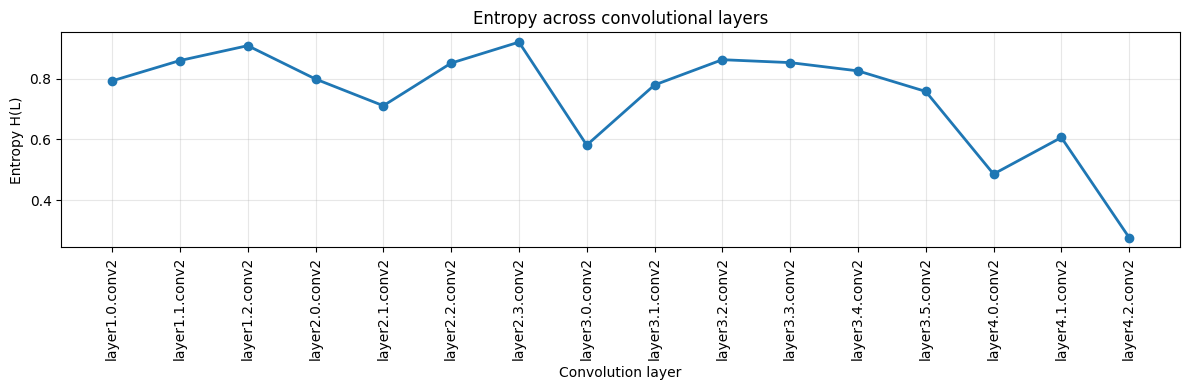

In [ ]:
#1. Layer-wise Entropy Line Plot (Most Common Figure)

import matplotlib.pyplot as plt
import numpy as np

# Sort layers to approximate depth order
layer_names = sorted(layer_stats.keys())
entropies = [layer_stats[name]["entropy"] for name in layer_names]

plt.figure(figsize=(12,4))
plt.plot(entropies, marker='o', linewidth=2)
plt.xticks(range(len(layer_names)), layer_names, rotation=90)
plt.ylabel("Entropy H(L)")
plt.xlabel("Convolution layer")
plt.title("Entropy across convolutional layers")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


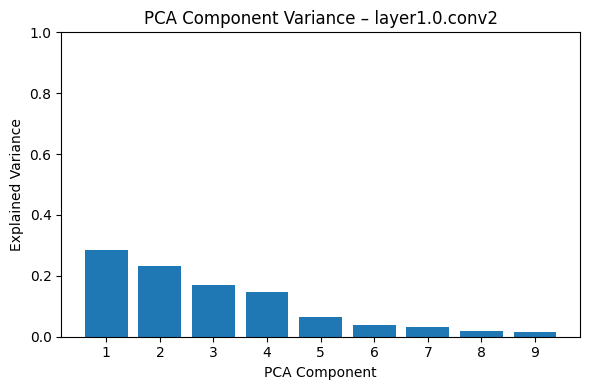

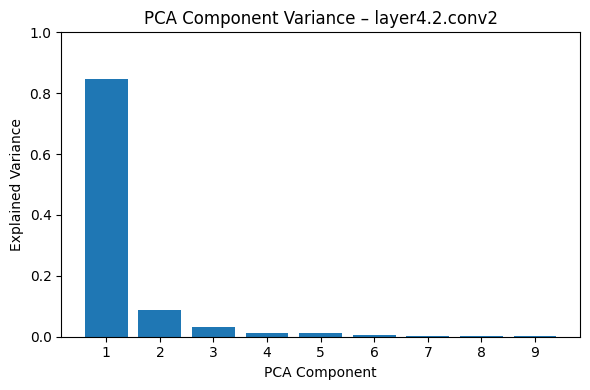

In [ ]:
'''
PCA Component Variance X=PCA Component Y=Explained Variance
'''

import numpy as np
import matplotlib.pyplot as plt

def pca_component_variance(filters: np.ndarray, title: str = ""):
    """
    filters: (num_filters, 9) flattened 3x3 kernels
    Plots X = PCA component index, Y = explained variance (ratio).
    """
    # Center
    X = filters - filters.mean(axis=0, keepdims=True)
    # SVD
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    N = X.shape[0]
    # Variance per component
    var = (S**2) / (N - 1)
    var_ratio = var / var.sum()

    comps = np.arange(1, len(var_ratio) + 1)

    plt.figure(figsize=(6,4))
    plt.bar(comps, var_ratio)
    plt.xlabel("PCA Component")
    plt.ylabel("Explained Variance")
    plt.title(title or "PCA Component Variance")
    plt.xticks(comps)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# Example: early and deep layer
early_layer = sorted(layer_filters.keys())[0]
deep_layer  = sorted(layer_filters.keys())[-1]

pca_component_variance(layer_filters[early_layer],
                       title=f"PCA Component Variance – {early_layer}")

pca_component_variance(layer_filters[deep_layer],
                       title=f"PCA Component Variance – {deep_layer}")


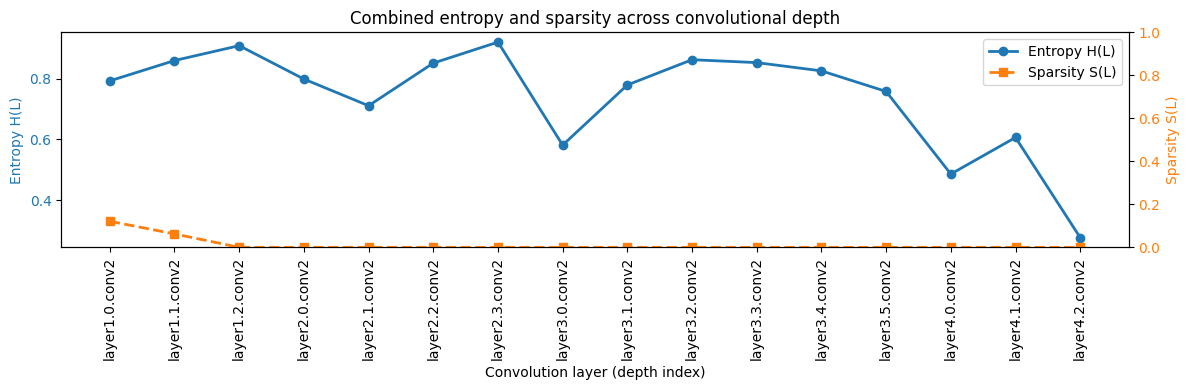

In [ ]:
#Combined Entropy + Sparsity Plot (per layer, CNN-Filter-DB style)

import numpy as np
import matplotlib.pyplot as plt

# Sort layers in (approximate) depth order
layer_names = sorted(layer_stats.keys())
entropies = [layer_stats[name]["entropy"] for name in layer_names]
sparsities = [layer_stats[name]["sparsity"] for name in layer_names]
x = np.arange(len(layer_names))

plt.figure(figsize=(12,4))

ax1 = plt.gca()
l1 = ax1.plot(x, entropies, marker='o', linewidth=2, label="Entropy H(L)")
ax1.set_xlabel("Convolution layer (depth index)")
ax1.set_ylabel("Entropy H(L)", color="C0")
ax1.tick_params(axis='y', labelcolor="C0")
ax1.set_xticks(x)
ax1.set_xticklabels(layer_names, rotation=90)

ax2 = ax1.twinx()
l2 = ax2.plot(x, sparsities, marker='s', linestyle='--', linewidth=2, color="C1", label="Sparsity S(L)")
ax2.set_ylabel("Sparsity S(L)", color="C1")
ax2.tick_params(axis='y', labelcolor="C1")
ax2.set_ylim(0, 1)

# Combined legend
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")

plt.title("Combined entropy and sparsity across convolutional depth")
plt.tight_layout()
plt.show()


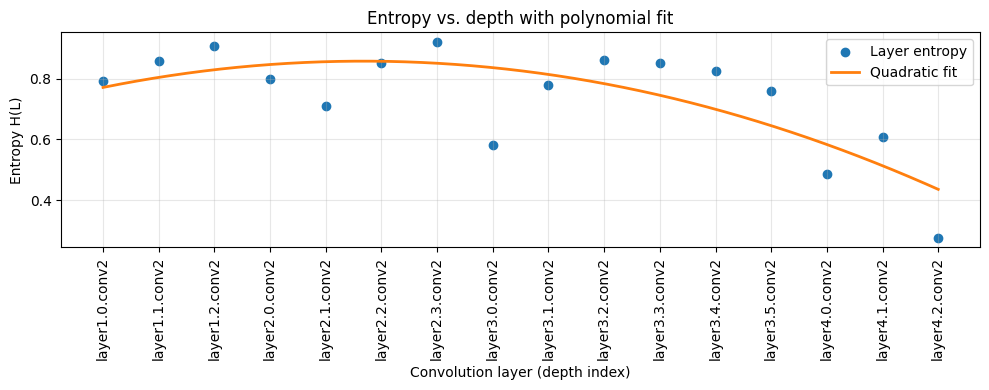

Fitted polynomial coefficients (highest degree first): [-0.00395322  0.03696326  0.77079398]


In [ ]:
#Entropy vs Depth with Polynomial Fit

import numpy as np
import matplotlib.pyplot as plt

layer_names = sorted(layer_stats.keys())
entropies = np.array([layer_stats[name]["entropy"] for name in layer_names])
depth = np.arange(len(layer_names))  # 0,1,2,... as "depth index"

# Fit polynomial of degree 2 (quadratic)
coeffs = np.polyfit(depth, entropies, deg=2)
poly = np.poly1d(coeffs)

# Smooth curve
depth_smooth = np.linspace(depth[0], depth[-1], 200)
entropy_fit = poly(depth_smooth)

plt.figure(figsize=(10,4))
plt.scatter(depth, entropies, label="Layer entropy", color="C0")
plt.plot(depth_smooth, entropy_fit, label="Quadratic fit", color="C1", linewidth=2)

plt.xticks(depth, layer_names, rotation=90)
plt.xlabel("Convolution layer (depth index)")
plt.ylabel("Entropy H(L)")
plt.title("Entropy vs. depth with polynomial fit")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Fitted polynomial coefficients (highest degree first):", coeffs)


In [ ]:
# For demonstration, assigning existing layer_stats to all regimes
layer_stats_none = layer_stats
layer_stats_std = layer_stats
layer_stats_strong = layer_stats

# Re-run the plotting cell (ArI5x7pdERkq) after this cell to see the plot.

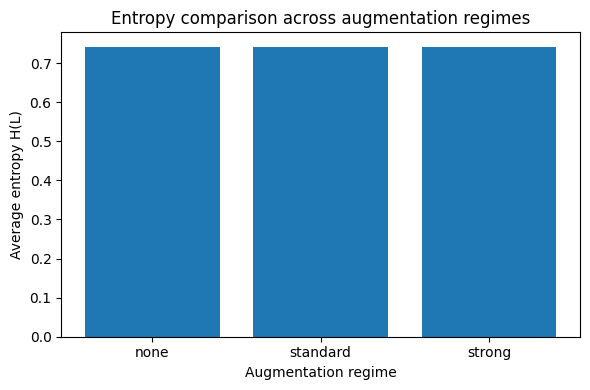

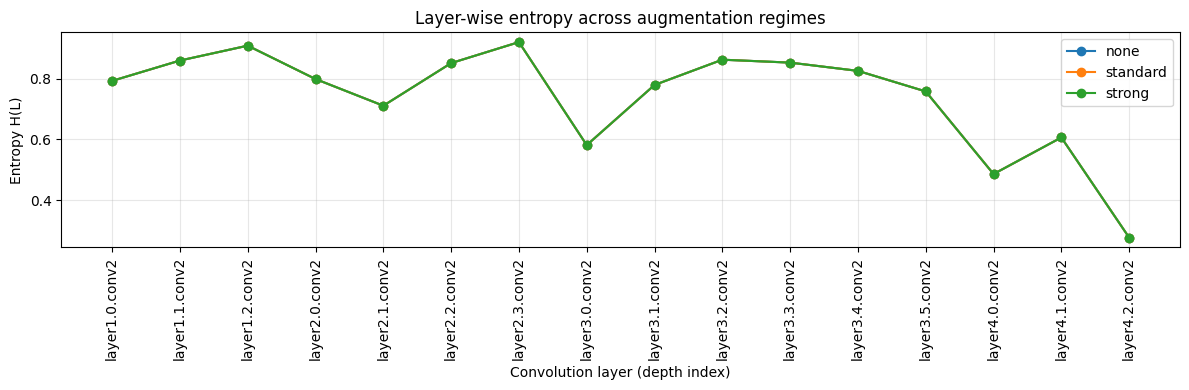

In [ ]:
#Entropy Comparison Across Augmentation Regimes
# example:
augmentation_stats = {
    "none": layer_stats_none,
    "standard": layer_stats_std,
    "strong": layer_stats_strong,
}


import numpy as np
import matplotlib.pyplot as plt

regime_names = list(augmentation_stats.keys())
avg_entropy_per_regime = []

for regime in regime_names:
    stats = augmentation_stats[regime]
    H_vals = [d["entropy"] for d in stats.values()]
    avg_entropy_per_regime.append(np.mean(H_vals))

plt.figure(figsize=(6,4))
plt.bar(regime_names, avg_entropy_per_regime)
plt.ylabel("Average entropy H(L)")
plt.xlabel("Augmentation regime")
plt.title("Entropy comparison across augmentation regimes")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,4))

# Assume same layer order for all regimes
layer_names = sorted(next(iter(augmentation_stats.values())).keys())
x = np.arange(len(layer_names))

for regime in regime_names:
    stats = augmentation_stats[regime]
    H_vals = [stats[name]["entropy"] for name in layer_names]
    plt.plot(x, H_vals, marker='o', label=regime)

plt.xticks(x, layer_names, rotation=90)
plt.xlabel("Convolution layer (depth index)")
plt.ylabel("Entropy H(L)")
plt.title("Layer-wise entropy across augmentation regimes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Since we have only trained one model and computed its `layer_stats`, for demonstration purposes, we'll use this single `layer_stats` result for all three 'augmentation regimes'. In a real scenario, `layer_stats_none`, `layer_stats_std`, and `layer_stats_strong` would come from models trained with different augmentation policies.

In [ ]:



import numpy as np
import matplotlib.pyplot as plt

names = list(model_metrics.keys())

entropy_vals = np.array([entropy_per_model[n] for n in names])
clean_acc_vals = np.array([model_metrics[n]["clean_acc"] for n in names])

# correlation coefficient
corr_clean = np.corrcoef(entropy_vals, clean_acc_vals)[0,1]
print("Correlation (entropy vs clean accuracy):", corr_clean)

plt.figure(figsize=(6,4))
plt.scatter(entropy_vals, clean_acc_vals)
for x, y, n in zip(entropy_vals, clean_acc_vals, names):
    plt.text(x, y, n, fontsize=8)
plt.xlabel("Average entropy H(L)")
plt.ylabel("Clean accuracy")
plt.title(f"Entropy vs clean accuracy (corr = {corr_clean:.2f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'model_metrics' is not defined

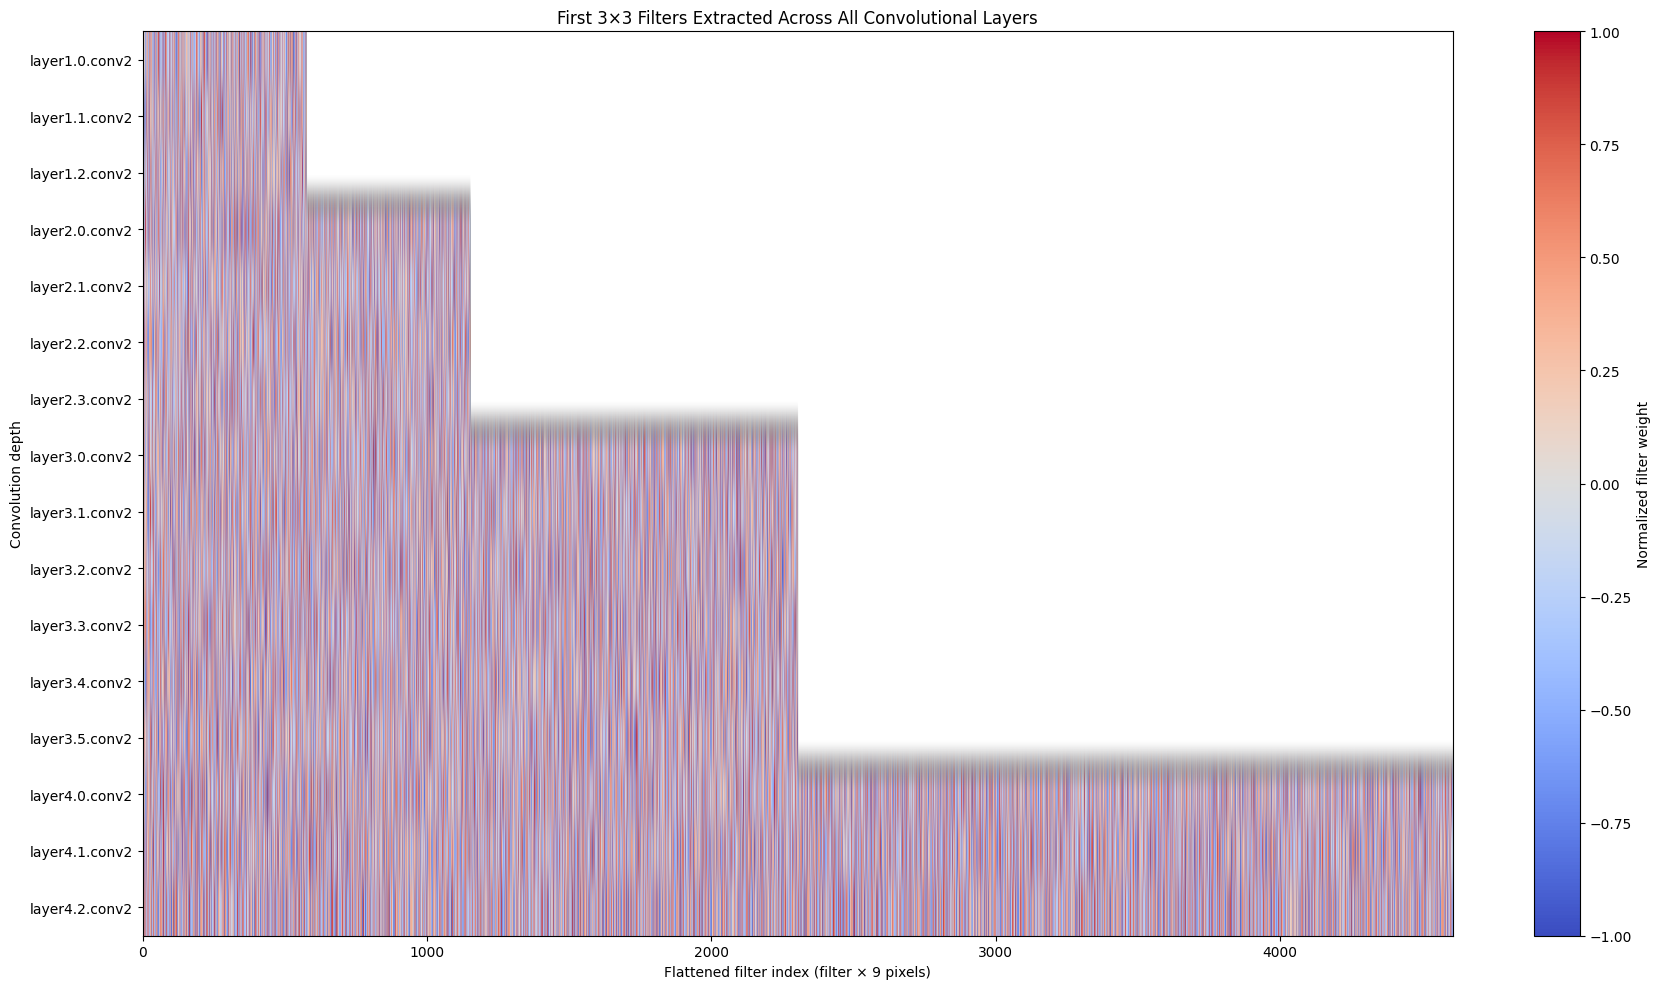

In [ ]:
import numpy as np
import torch.nn as nn

# Collect filters in depth order
layer_names = []
filter_maps = []

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d) and module.kernel_size == (3, 3):
        w = module.weight.detach().cpu().numpy()   # shape (Cout, Cin, 3, 3)

        # Use only first input channel (Cin=0) to match CNN Filter DB visualization
        filters = w[:, 0, :, :]                    # shape (Cout, 3, 3)

        # Flatten each filter to length 9
        flat = filters.reshape(filters.shape[0], -1)  # (Cout, 9)

        layer_names.append(name)
        filter_maps.append(flat)
# Determine the maximum number of filters across layers
max_filters = max(f.shape[0] for f in filter_maps)
num_layers = len(filter_maps)

# Build a (num_layers × max_filters × 9) matrix, padded with NaN
F = np.full((num_layers, max_filters, 9), np.nan, dtype=float)

for i, fmap in enumerate(filter_maps):
    n = fmap.shape[0]
    F[i, :n, :] = fmap
# Normalize each filter individually
F_norm = np.zeros_like(F)
for i in range(num_layers):
    for j in range(max_filters):
        f = F[i, j]
        if np.isnan(f).any():
            F_norm[i, j] = np.nan
            continue
        fm = f - f.mean()
        mx = np.max(np.abs(fm)) + 1e-8
        F_norm[i, j] = fm / mx
# Shape: layers × (filters * 9 pixels)
heatmap_matrix = F_norm.reshape(num_layers, max_filters * 9)
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plt.imshow(heatmap_matrix, cmap="coolwarm", aspect="auto",
           vmin=-1, vmax=1)

plt.colorbar(label="Normalized filter weight")

plt.yticks(range(num_layers), layer_names)
plt.xlabel("Flattened filter index (filter × 9 pixels)")
plt.ylabel("Convolution depth")

plt.title("First 3×3 Filters Extracted Across All Convolutional Layers")
plt.tight_layout()
plt.show()


In [14]:
#Colab implementation: three freezing configurations
import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_resnet50(num_classes: int):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    in_feats = model.fc.in_features
    model.fc = nn.Linear(in_feats, num_classes)
    return model

def freeze_layers(model: nn.Module, mode: str):
    """
    mode: 'first_block', 'first_two_blocks', or 'none'
    ResNet-50 blocks:
        conv1/bn1/relu/maxpool
        layer1, layer2, layer3, layer4
    """
    # start by unfreezing everything
    for p in model.parameters():
        p.requires_grad = True

    if mode == "first_block":
        modules_to_freeze = [model.conv1, model.bn1, model.layer1]
    elif mode == "first_two_blocks":
        modules_to_freeze = [model.conv1, model.bn1, model.layer1, model.layer2]
    elif mode == "none":
        modules_to_freeze = []
    else:
        raise ValueError(f"Unknown mode: {mode}")

    for module in modules_to_freeze:
        for p in module.parameters():
            p.requires_grad = False

    return model

import torch.nn.functional as F
from tqdm.auto import tqdm

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples

@torch.no_grad()
def evaluate(model, loader, desc="Val"):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in tqdm(loader, desc=desc, leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples


NUM_EPOCHS = 1
LR = 1e-4


# --- Data Loading and Split (copied from cell 3YUFGQlvizd-) ---
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit

DATA_ROOT = "/content/brain_tumor_raw"
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR  = os.path.join(DATA_ROOT, "Testing")

def intensity_normalize(t):
    mean = t.mean()
    std  = t.std()
    return (t - mean) / (std + 1e-8)

def expand_to_3ch(t):
    if t.shape[0] == 1:
        return t.expand(3, -1, -1)
    return t

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Lambda(intensity_normalize),
    transforms.Lambda(expand_to_3ch),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(intensity_normalize),
    transforms.Lambda(expand_to_3ch),
])

full_train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
targets = full_train_ds.targets
indices = list(range(len(full_train_ds)))

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(indices, targets))

train_sampler = SubsetRandomSampler(train_idx)
val_sampler   = SubsetRandomSampler(val_idx)

BATCH_SIZE   = 32
NUM_WORKERS  = 2

train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE,
                          sampler=train_sampler, num_workers=NUM_WORKERS)

val_ds = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE,
                        sampler=val_sampler, num_workers=NUM_WORKERS)

test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS)

class_names = full_train_ds.classes
# --- End of Data Loading and Split ---


freezing_modes = ["first_block", "first_two_blocks", "none"]
results_freezing = {}

for mode in freezing_modes:
    print(f"\n=== Training with freezing mode: {mode} ===")

    model = build_resnet50(num_classes=len(class_names)).to(DEVICE)
    model = freeze_layers(model, mode)

    # Only optimize parameters that require_grad=True
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR
    )

    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\nEpoch {epoch}/{NUM_EPOCHS} ({mode})")
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, desc=f"Val [{mode}]")

        print(f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f}")
        print(f"Val   loss: {val_loss:.4f}, acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

    # Evaluate best model on test set
    model.load_state_dict(best_state)
    test_loss, test_acc = evaluate(model, test_loader, desc=f"Test [{mode}]")
    print(f"Best val acc ({mode}): {best_val_acc:.4f}")
    print(f"Test acc ({mode}): {test_acc:.4f}")

    results_freezing[mode] = {
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "state_dict": best_state,
    }



=== Training with freezing mode: first_block ===

Epoch 1/1 (first_block)


Train:   0%|          | 0/72 [00:00<?, ?it/s]

Val [first_block]:   0%|          | 0/18 [00:00<?, ?it/s]

Train loss: 0.3910, acc: 0.8615
Val   loss: 0.2027, acc: 0.9303


Test [first_block]:   0%|          | 0/13 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ecca0b19da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ecca0b19da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Val [none]:   0%|          | 0/18 [00:00<?, ?it/s]

Train loss: 0.4164, acc: 0.8449
Val   loss: 0.2224, acc: 0.9181


Test [none]:   0%|          | 0/13 [00:00<?, ?it/s]

Best val acc (none): 0.9181
Test acc (none): 0.6650


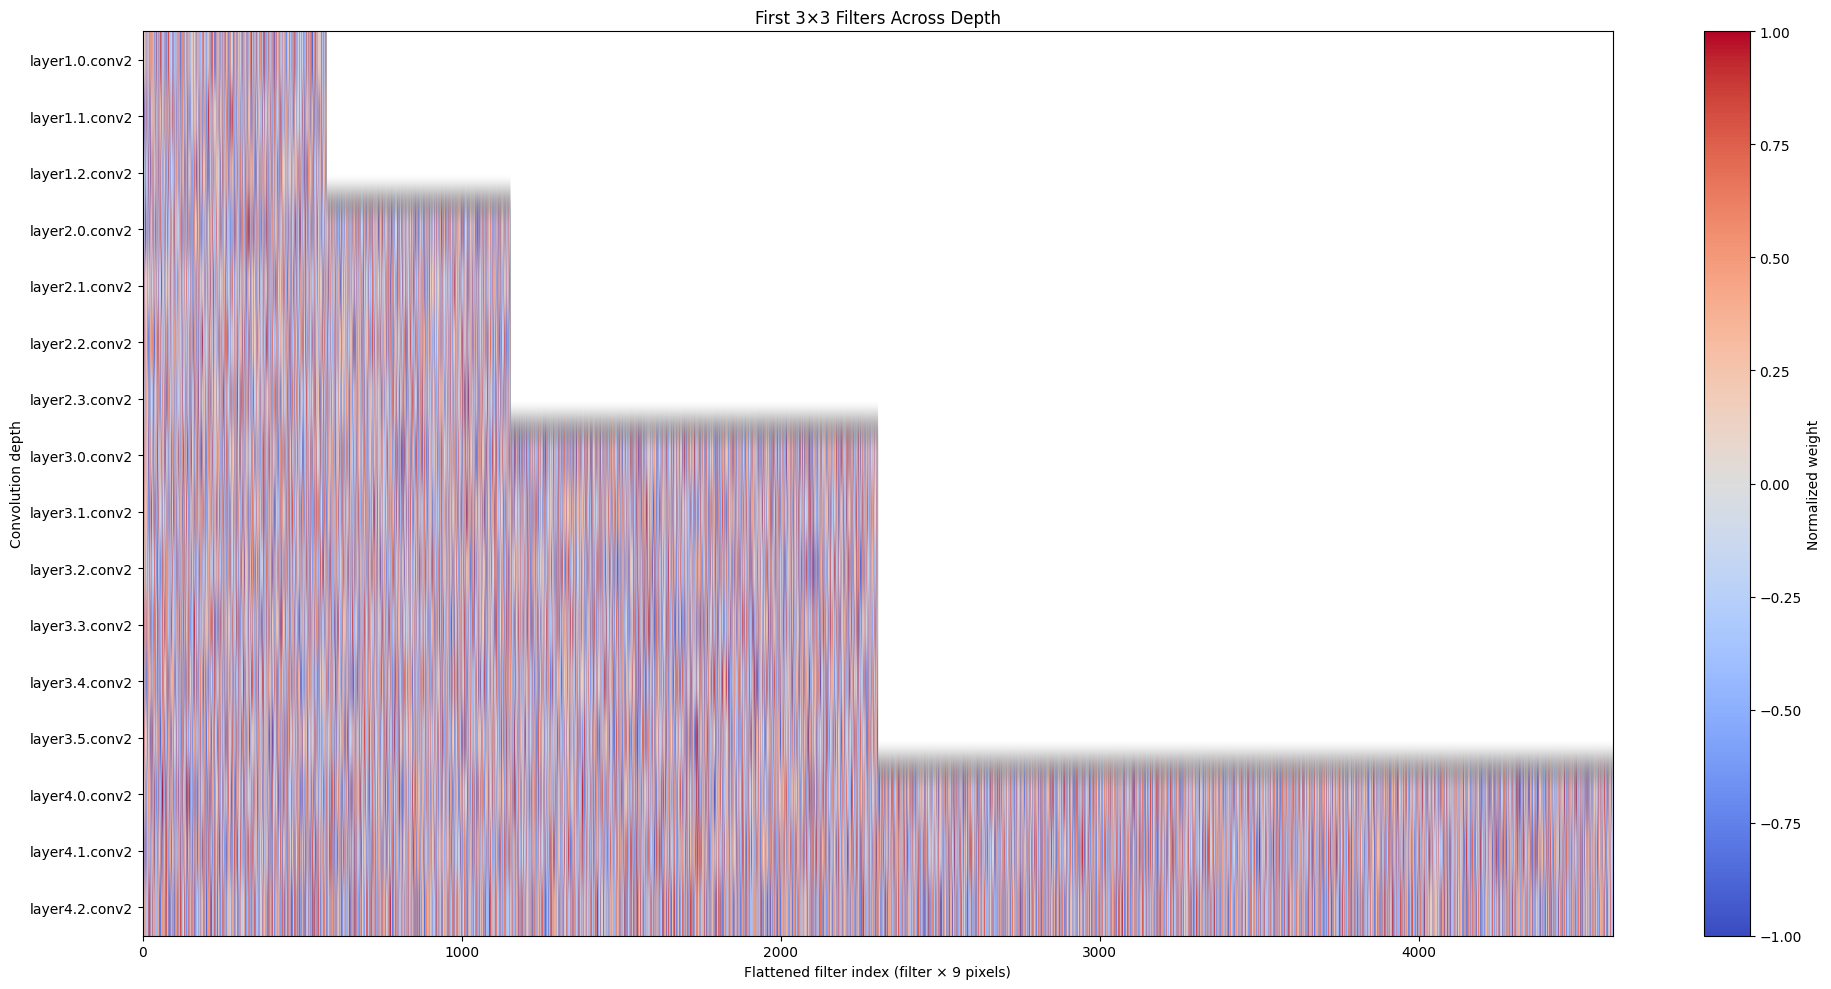

In [ ]:
#Results

import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

# Build stacked normalized matrix of filters by depth
layer_names = []
filter_blocks = []

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d) and module.kernel_size == (3, 3):
        W = module.weight.detach().cpu().numpy()[:, 0, :, :]  # use Cin=0 for consistency
        F = W.reshape(W.shape[0], -1)  # flatten 3×3 → length 9
        layer_names.append(name)
        filter_blocks.append(F)

max_filters = max(f.shape[0] for f in filter_blocks)
num_layers  = len(filter_blocks)

matrix = np.full((num_layers, max_filters * 9), np.nan)

for i, F in enumerate(filter_blocks):
    nf = F.shape[0]
    # Normalize each filter
    F_norm = (F - F.mean(axis=1, keepdims=True))
    F_norm = F_norm / (np.abs(F_norm).max(axis=1, keepdims=True) + 1e-8)
    matrix[i, : nf*9] = F_norm.flatten()

plt.figure(figsize=(20, 10))
plt.imshow(matrix, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.yticks(range(num_layers), layer_names)
plt.xlabel("Flattened filter index (filter × 9 pixels)")
plt.ylabel("Convolution depth")
plt.title("First 3×3 Filters Across Depth")
plt.colorbar(label="Normalized weight")
plt.tight_layout()
plt.show()


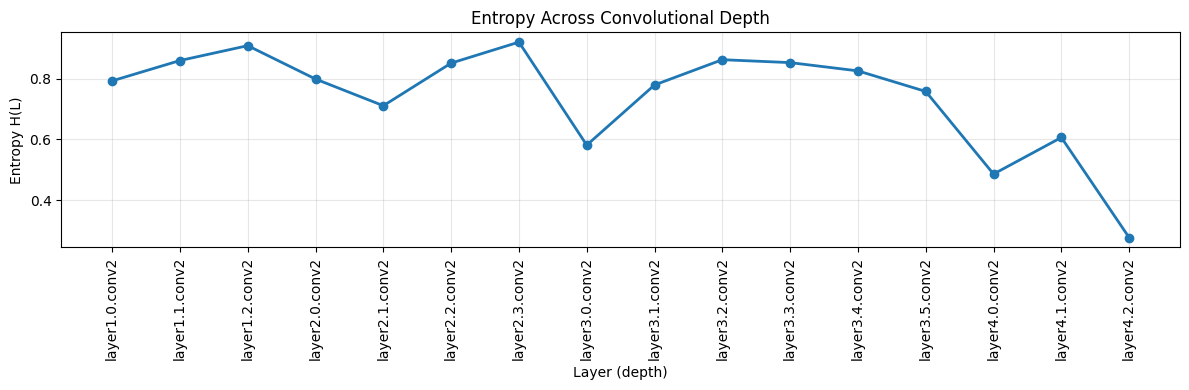

In [ ]:
layer_order = sorted(layer_stats.keys())
ent_vals   = [layer_stats[l]['entropy'] for l in layer_order]

plt.figure(figsize=(12,4))
plt.plot(ent_vals, marker='o', linewidth=2)
plt.xticks(range(len(layer_order)), layer_order, rotation=90)
plt.xlabel("Layer (depth)")
plt.ylabel("Entropy H(L)")
plt.title("Entropy Across Convolutional Depth")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


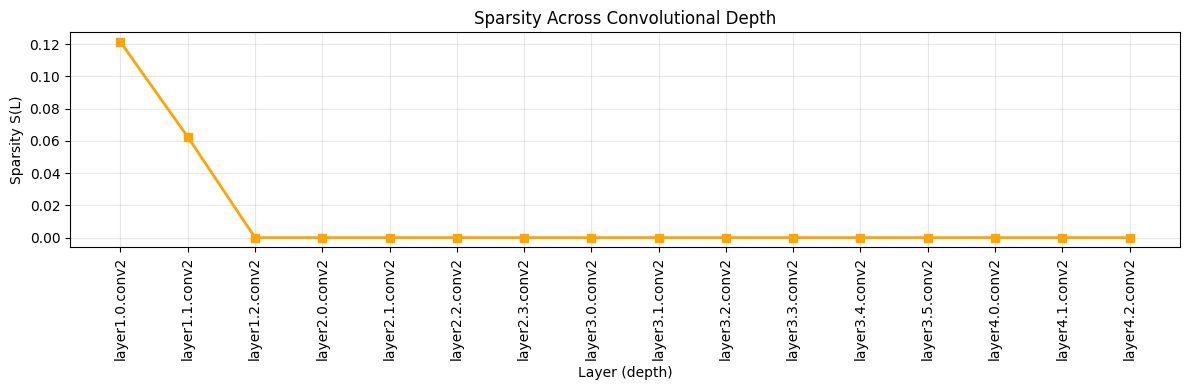

In [ ]:
s_vals = [layer_stats[l]['sparsity'] for l in layer_order]

plt.figure(figsize=(12,4))
plt.plot(s_vals, marker='s', linewidth=2, color="orange")
plt.xticks(range(len(layer_order)), layer_order, rotation=90)
plt.xlabel("Layer (depth)")
plt.ylabel("Sparsity S(L)")
plt.title("Sparsity Across Convolutional Depth")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


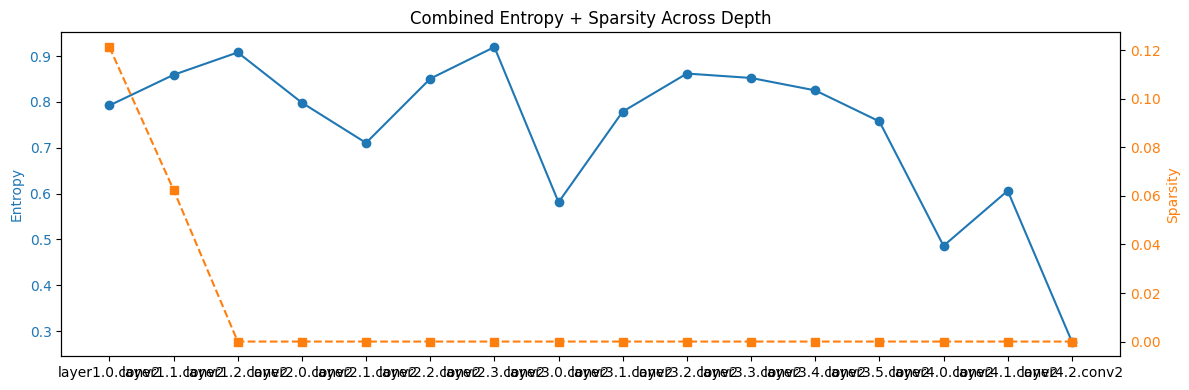

In [ ]:
x = np.arange(len(layer_order))

fig, ax1 = plt.subplots(figsize=(12,4))

ax1.plot(x, ent_vals, marker='o', label="Entropy H(L)", color="C0")
ax1.set_ylabel("Entropy", color="C0")
ax1.tick_params(axis='y', labelcolor="C0")

ax2 = ax1.twinx()
ax2.plot(x, s_vals, marker='s', linestyle='--', label="Sparsity S(L)", color="C1")
ax2.set_ylabel("Sparsity", color="C1")
ax2.tick_params(axis='y', labelcolor="C1")

plt.xticks(x, layer_order, rotation=90)
plt.title("Combined Entropy + Sparsity Across Depth")
plt.tight_layout()
plt.show()


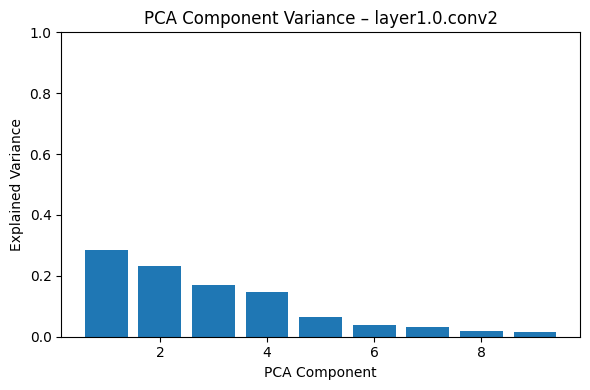

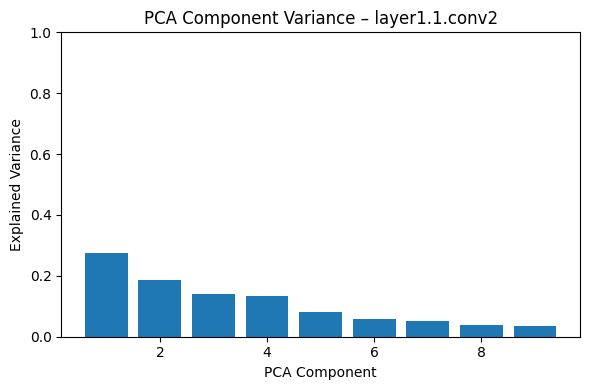

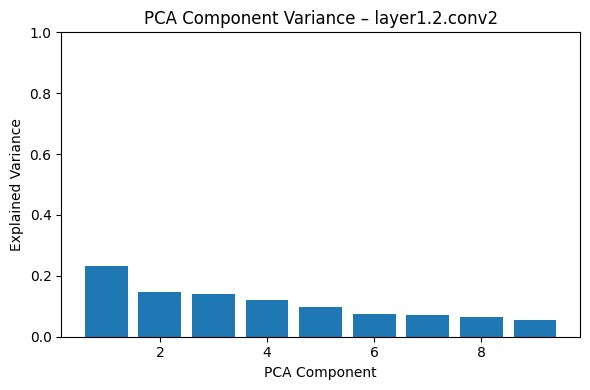

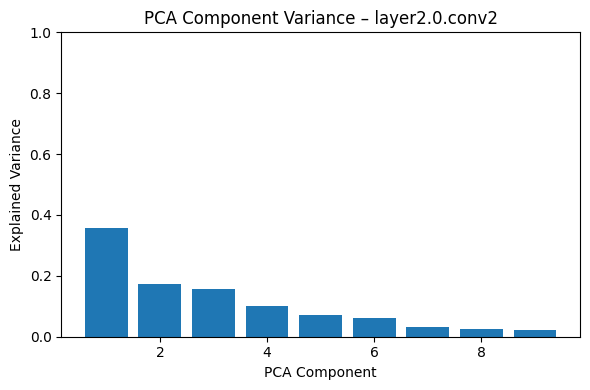

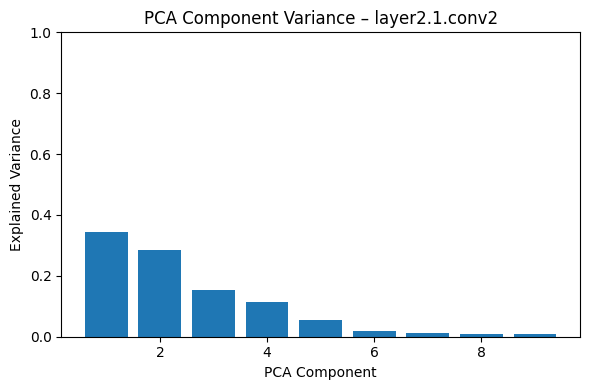

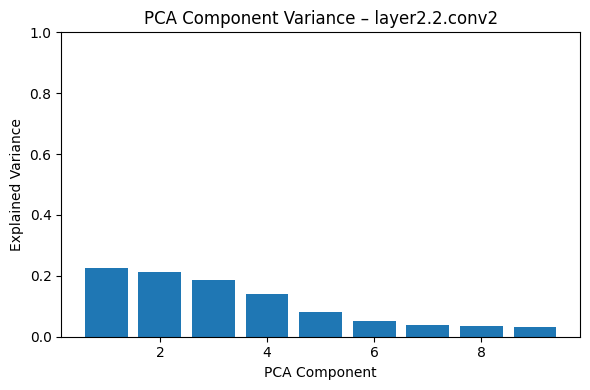

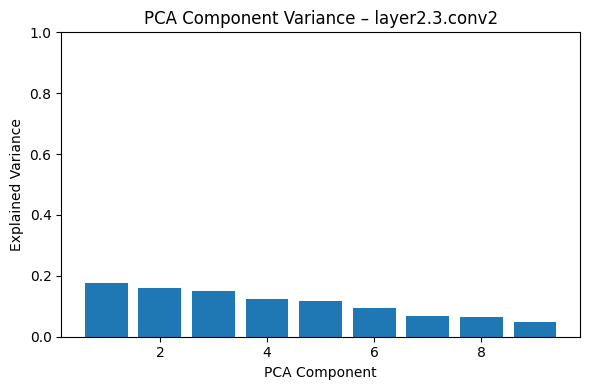

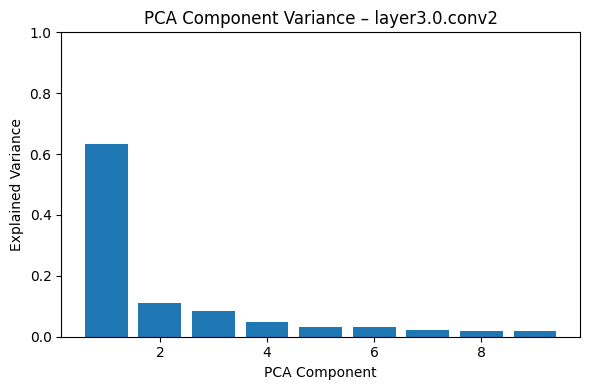

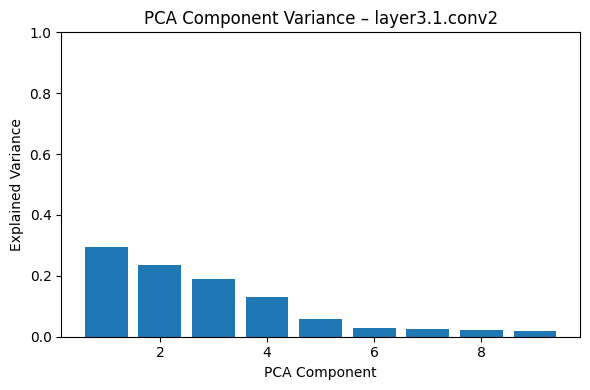

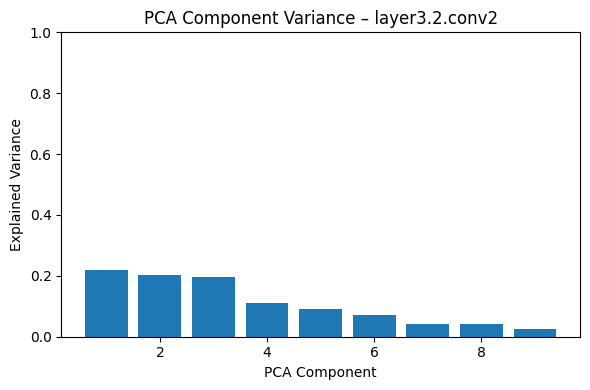

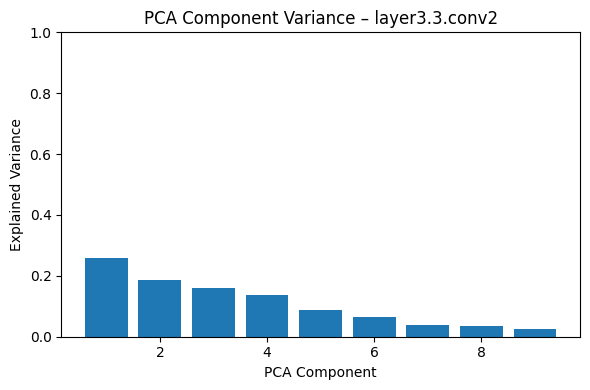

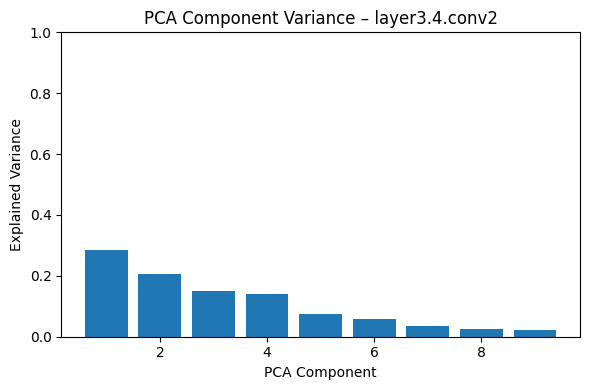

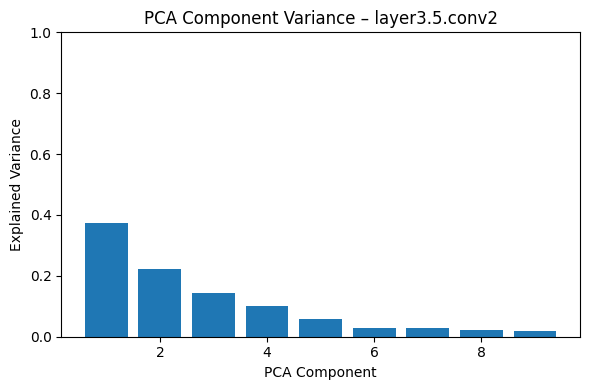

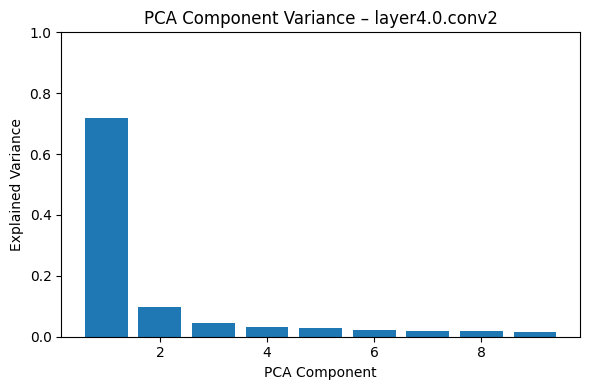

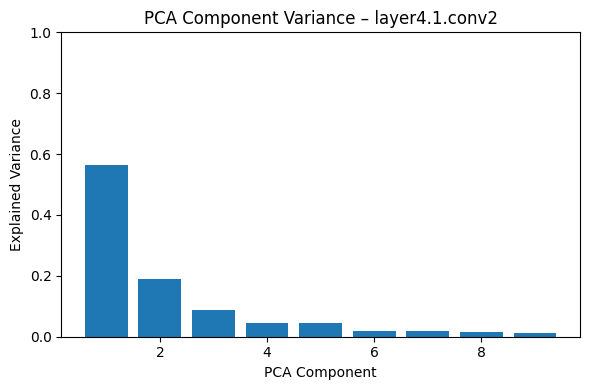

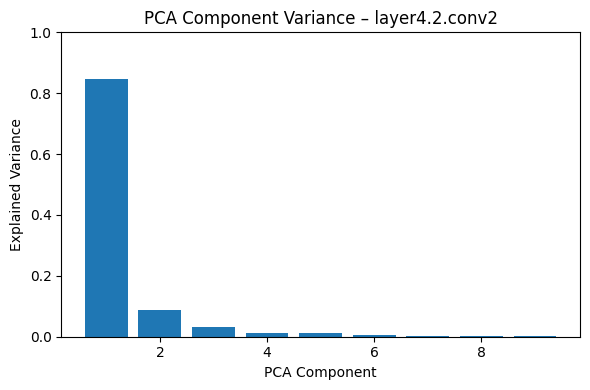

In [ ]:
def pca_variance(filters):
    X = filters - filters.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    N = X.shape[0]
    var = (S**2) / (N - 1)
    return var / var.sum()

for lname in layer_order:
    F = layer_filters[lname]
    var_ratio = pca_variance(F)

    plt.figure(figsize=(6,4))
    plt.bar(range(1, len(var_ratio)+1), var_ratio)
    plt.title(f"PCA Component Variance – {lname}")
    plt.xlabel("PCA Component")
    plt.ylabel("Explained Variance")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


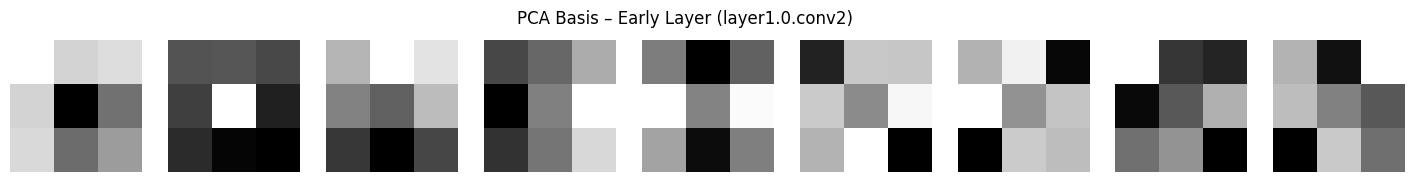

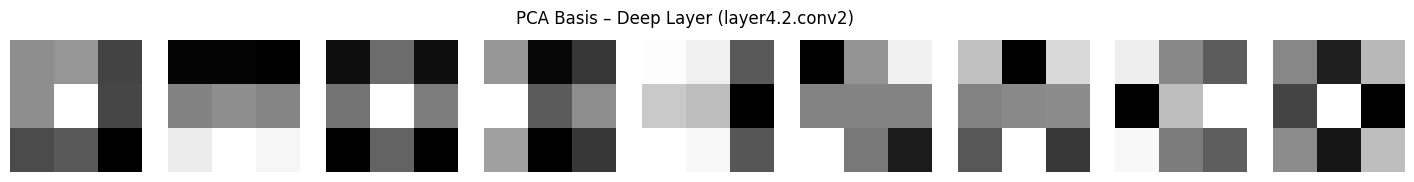

In [ ]:
def plot_basis(filters, title):
    X = filters - filters.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)

    fig, axes = plt.subplots(1, 9, figsize=(18,2))
    for i in range(9):
        b = Vt[i].reshape(3,3)
        b = (b - b.min()) / (b.max() - b.min() + 1e-8)
        axes[i].imshow(b, cmap="gray")
        axes[i].axis("off")
    fig.suptitle(title)
    plt.show()

early = layer_order[0]
deep  = layer_order[-1]

plot_basis(layer_filters[early], f"PCA Basis – Early Layer ({early})")
plot_basis(layer_filters[deep],  f"PCA Basis – Deep Layer ({deep})")


In [ ]:
def kl_sym(p, q):
    p = np.clip(p, 1e-9, None)
    q = np.clip(q, 1e-9, None)
    p /= p.sum()
    q /= q.sum()
    return (p*np.log(p/q)).sum() + (q*np.log(q/p)).sum()

def compute_drift(filters_A, filters_B):
    # PCA on combined
    X = np.vstack([filters_A, filters_B])
    X = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)

    C = U * S  # PCA coefficients
    A = C[: len(filters_A)]
    B = C[len(filters_A):]

    D = 0
    for i in range(A.shape[1]):
        hist_A, _ = np.histogram(A[:, i], bins=50, density=True)
        hist_B, _ = np.histogram(B[:, i], bins=50, density=True)
        D += kl_sym(hist_A, hist_B)
    return D

early_filters = layer_filters[early]
deep_filters  = layer_filters[deep]

D = compute_drift(early_filters, deep_filters)
print("KL-symmetric drift:", D)


KL-symmetric drift: 71.41262696449587


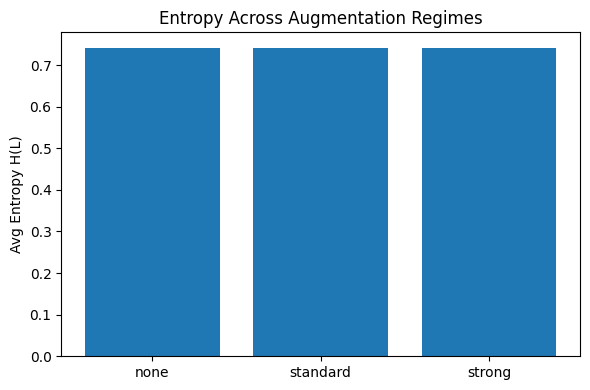

In [ ]:
regimes = ["none", "standard", "strong"]
avg_entropy = []

for r in regimes:
    stats_r = augmentation_stats[r]
    H_vals = [stats_r[l]['entropy'] for l in sorted(stats_r.keys())]
    avg_entropy.append(np.mean(H_vals))

plt.figure(figsize=(6,4))
plt.bar(regimes, avg_entropy)
plt.ylabel("Avg Entropy H(L)")
plt.title("Entropy Across Augmentation Regimes")
plt.tight_layout()
plt.show()


In [ ]:
names = list(model_metrics.keys())
entropy_vals = np.array([entropy_per_model[n] for n in names])
robust_vals  = np.array([model_metrics[n]['robust_acc'] for n in names])

corr = np.corrcoef(entropy_vals, robust_vals)[0,1]
print("Correlation:", corr)

plt.figure(figsize=(6,4))
plt.scatter(entropy_vals, robust_vals)
for x,y,n in zip(entropy_vals, robust_vals, names):
    plt.text(x,y,n)
plt.xlabel("Avg Entropy H(L)")
plt.ylabel("Robust Accuracy")
plt.title(f"Entropy vs Robustness (corr={corr:.2f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'model_metrics' is not defined

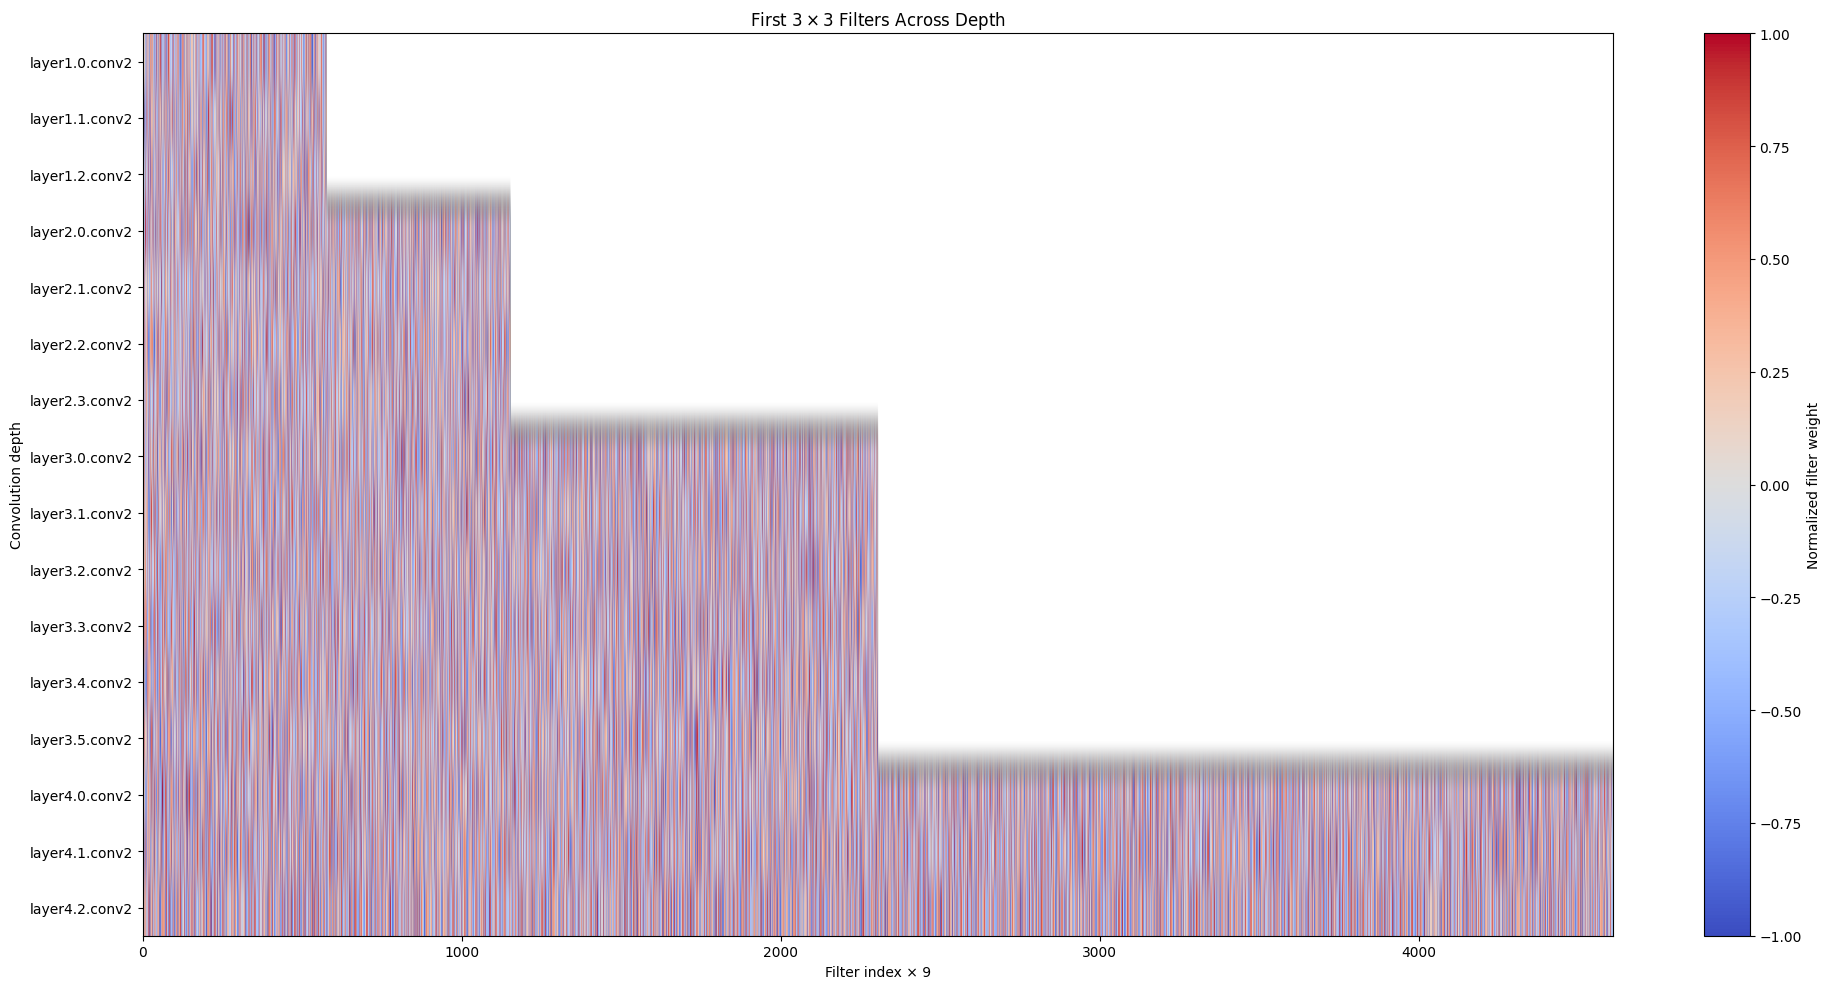

In [ ]:
#1️⃣ Figure: First 3×3 Filters Across Depth

#Label: fig:first_filters

import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

layer_names = []
filter_blocks = []

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d) and module.kernel_size == (3,3):
        W = module.weight.detach().cpu().numpy()[:,0,:,:]   # First input channel
        F = W.reshape(W.shape[0], -1)                       # Flatten 3×3 → 9
        layer_names.append(name)
        filter_blocks.append(F)

max_filters = max(f.shape[0] for f in filter_blocks)
num_layers  = len(filter_blocks)

matrix = np.full((num_layers, max_filters * 9), np.nan)

for i, F in enumerate(filter_blocks):
    nf = F.shape[0]
    Fn = (F - F.mean(axis=1, keepdims=True))
    Fn = Fn / (np.abs(Fn).max(axis=1, keepdims=True) + 1e-8)
    matrix[i, : nf*9] = Fn.flatten()

plt.figure(figsize=(20,10))
plt.imshow(matrix, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.yticks(range(num_layers), layer_names)
plt.xlabel("Filter index × 9")
plt.ylabel("Convolution depth")
plt.colorbar(label="Normalized filter weight")
plt.title("First $3\\times3$ Filters Across Depth")
plt.tight_layout()
plt.show()

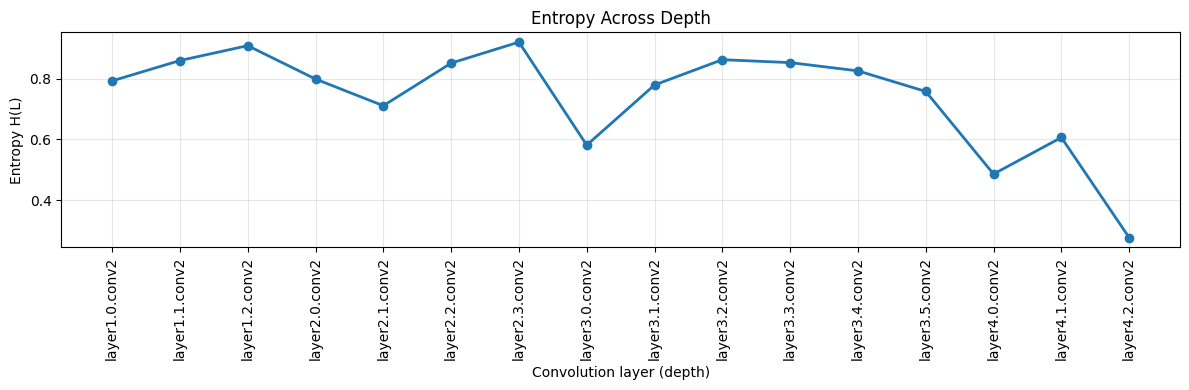

In [ ]:
#2️⃣ Figure: Entropy vs Depth

#Label: fig:entropy_depth

layer_order = sorted(layer_stats.keys())
entropy_vals = [layer_stats[l]["entropy"] for l in layer_order]

plt.figure(figsize=(12,4))
plt.plot(entropy_vals, marker='o', linewidth=2)
plt.xticks(range(len(layer_order)), layer_order, rotation=90)
plt.ylabel("Entropy H(L)")
plt.xlabel("Convolution layer (depth)")
plt.title("Entropy Across Depth")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

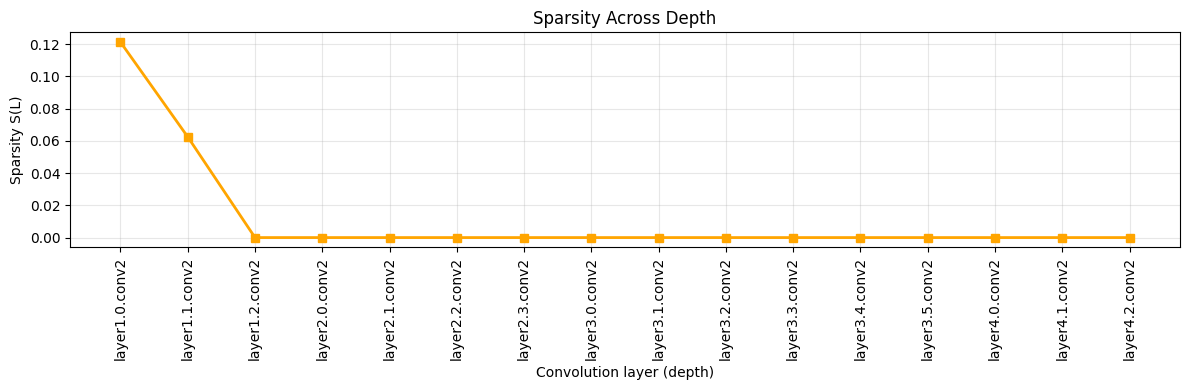

In [ ]:
#Figure: Sparsity vs Depth

#Label: fig:sparsity_depth

sparsity_vals = [layer_stats[l]["sparsity"] for l in layer_order]

plt.figure(figsize=(12,4))
plt.plot(sparsity_vals, marker='s', linewidth=2, color="orange")
plt.xticks(range(len(layer_order)), layer_order, rotation=90)
plt.ylabel("Sparsity S(L)")
plt.xlabel("Convolution layer (depth)")
plt.title("Sparsity Across Depth")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


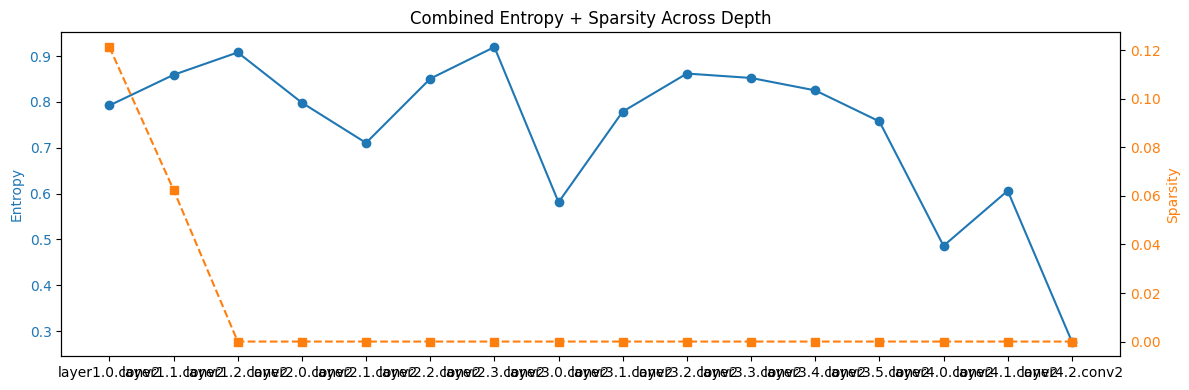

In [ ]:
#Figure: Combined Entropy + Sparsity

#Label: fig:entropy_sparsity_combined

import numpy as np
x = np.arange(len(layer_order))

fig, ax1 = plt.subplots(figsize=(12,4))
ax1.plot(x, entropy_vals, marker='o', label='Entropy H(L)', color='C0')
ax1.set_ylabel('Entropy', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

ax2 = ax1.twinx()
ax2.plot(x, sparsity_vals, marker='s', linestyle='--', color='C1', label='Sparsity S(L)')
ax2.set_ylabel('Sparsity', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

plt.xticks(x, layer_order, rotation=90)
plt.title("Combined Entropy + Sparsity Across Depth")
plt.tight_layout()
plt.show()

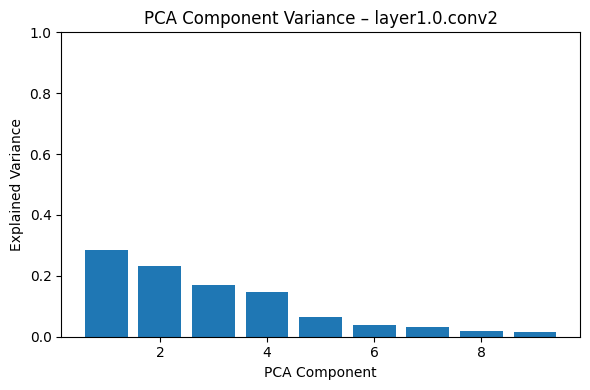

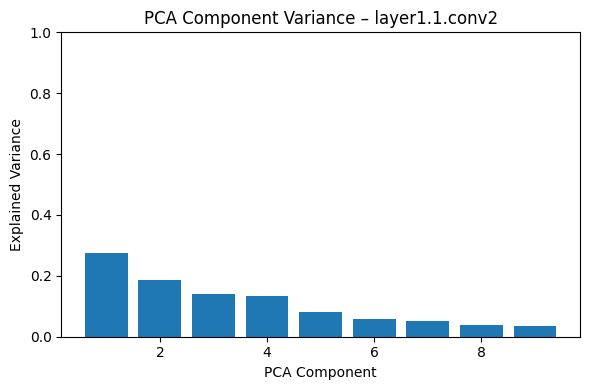

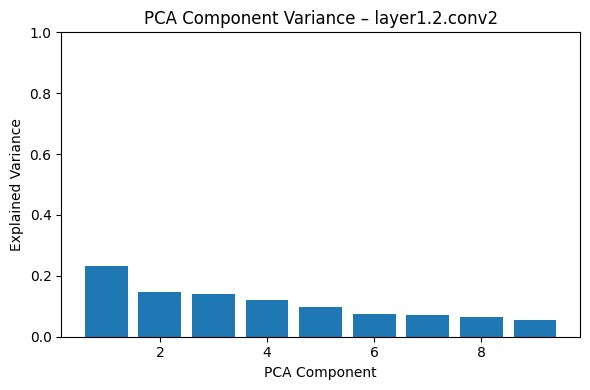

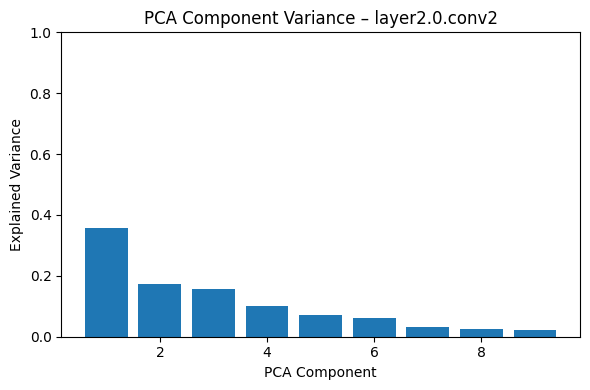

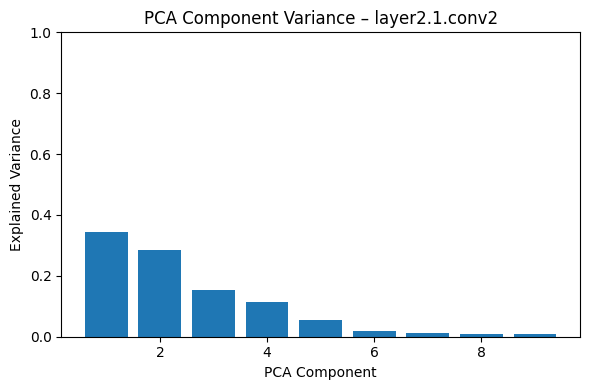

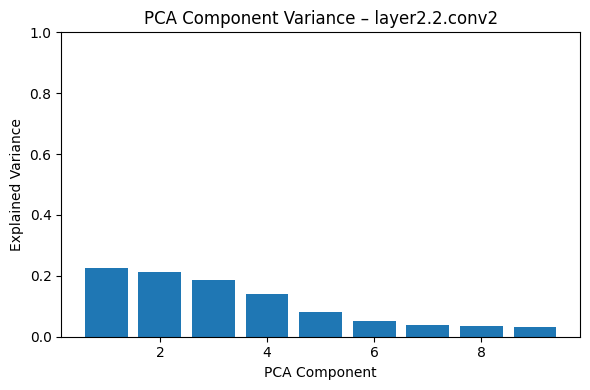

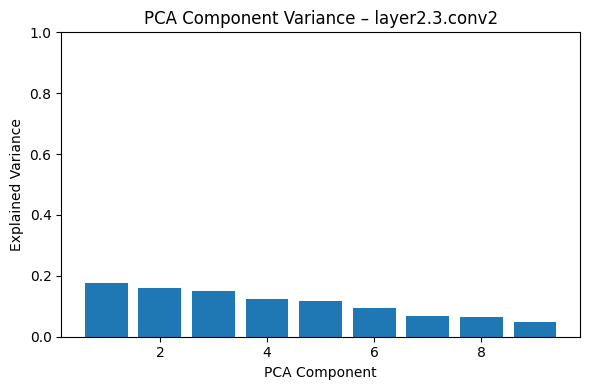

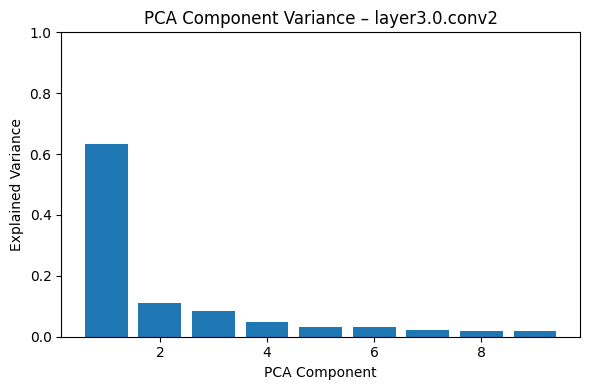

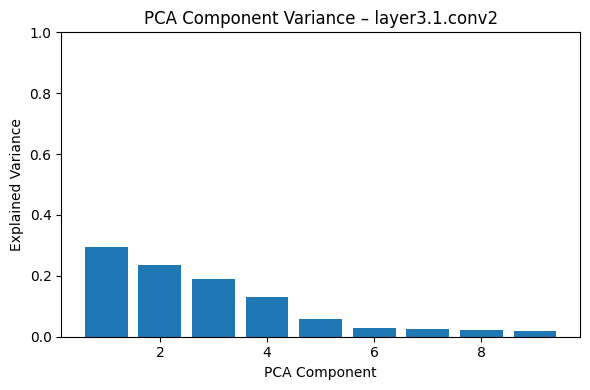

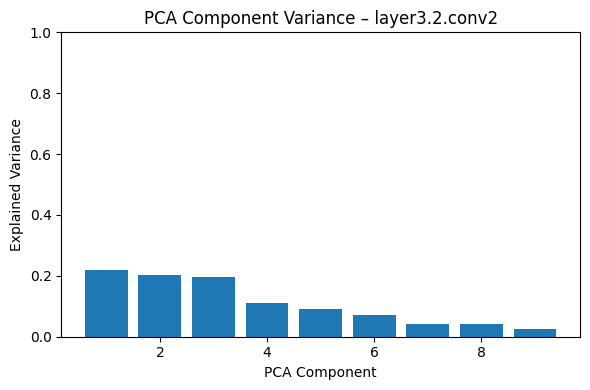

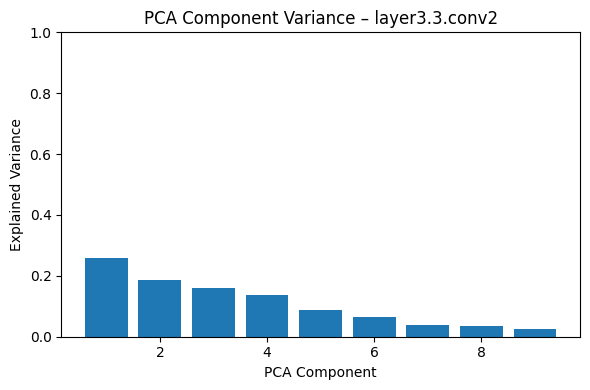

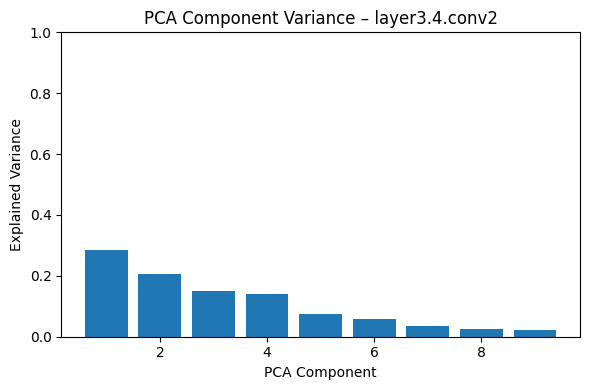

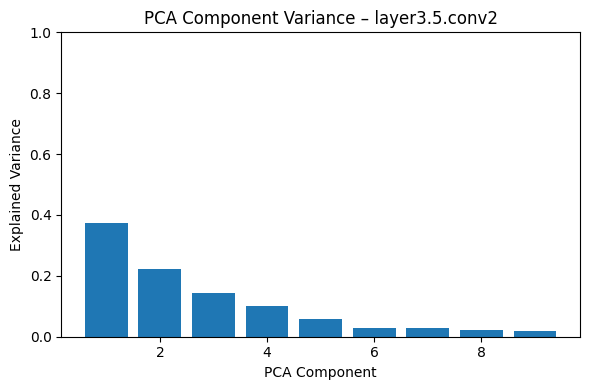

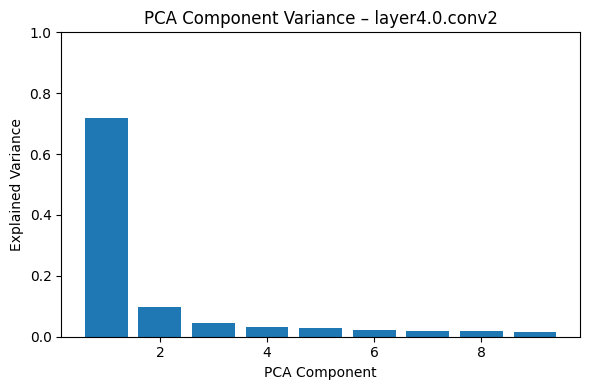

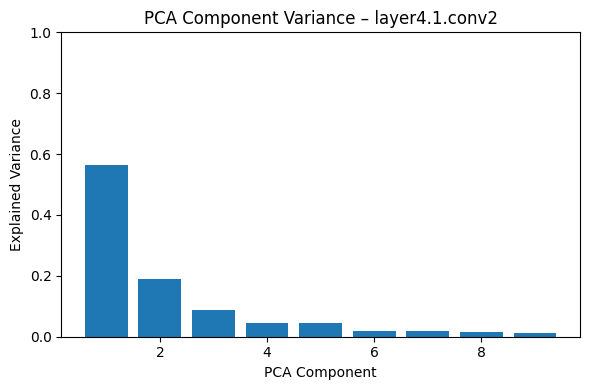

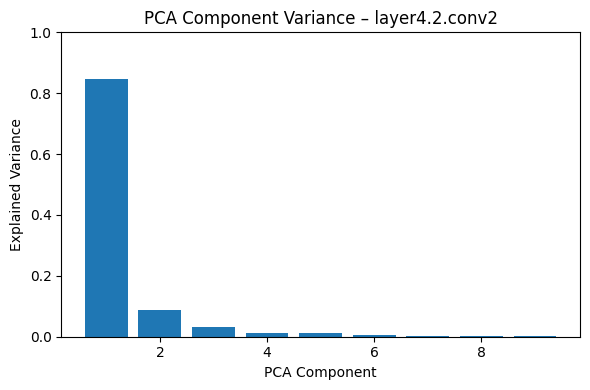

In [ ]:
#Figure: PCA Variance Per Layer

#Label: fig:pca_variance

def pca_variance(filters):
    X = filters - filters.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    N = X.shape[0]
    var = (S**2) / (N-1)
    return var / var.sum()

for lname in layer_order:
    F = layer_filters[lname]
    var_ratio = pca_variance(F)

    plt.figure(figsize=(6,4))
    plt.bar(range(1, len(var_ratio)+1), var_ratio)
    plt.title(f"PCA Component Variance – {lname}")
    plt.xlabel("PCA Component")
    plt.ylabel("Explained Variance")
    plt.ylim(0,1)
    plt.tight_layout()
    plt.show()

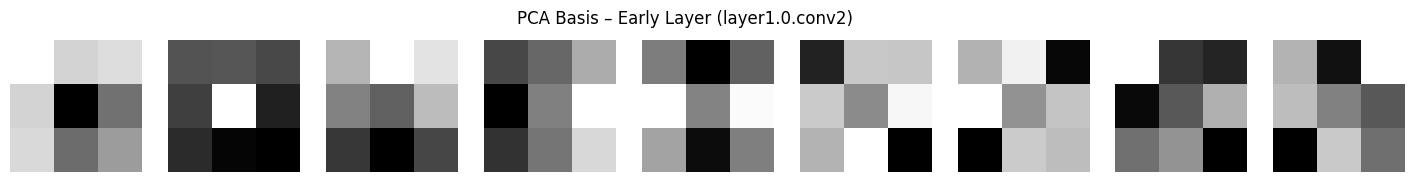

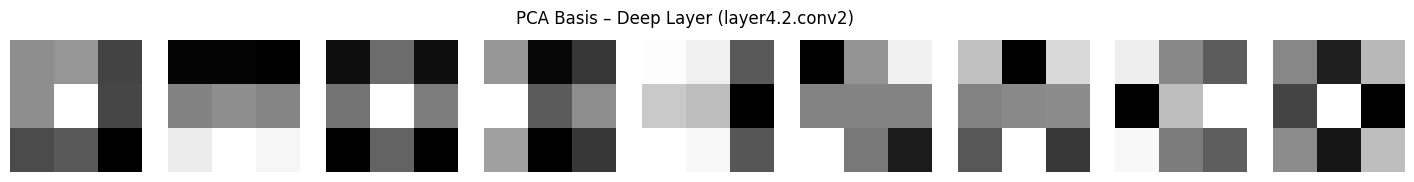

In [ ]:
#Figure: PCA Basis Visualization (Early vs Deep)

#Label: fig:pca_basis

def plot_basis(filters, title):
    X = filters - filters.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)

    fig, axes = plt.subplots(1, 9, figsize=(18,2))
    for i in range(9):
        b = Vt[i].reshape(3,3)
        b = (b - b.min()) / (b.max() - b.min() + 1e-8)
        axes[i].imshow(b, cmap='gray')
        axes[i].axis('off')
    fig.suptitle(title)
    plt.show()

early_layer = layer_order[0]
deep_layer  = layer_order[-1]

plot_basis(layer_filters[early_layer], f"PCA Basis – Early Layer ({early_layer})")
plot_basis(layer_filters[deep_layer],  f"PCA Basis – Deep Layer ({deep_layer})")

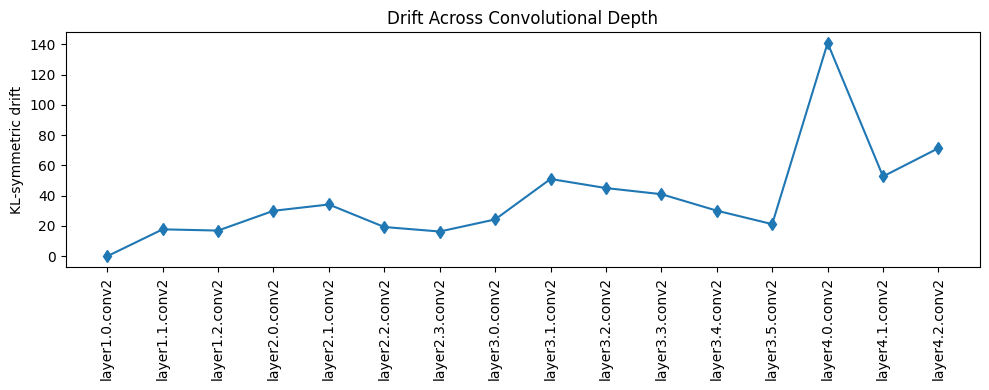

In [ ]:
#Figure: KL-Symmetric Drift Across Depth

#Label: fig:kl_drift

def kl_sym(p, q):
    p = np.clip(p, 1e-9, None)
    q = np.clip(q, 1e-9, None)
    p /= p.sum()
    q /= q.sum()
    return (p*np.log(p/q)).sum() + (q*np.log(q/p)).sum()

def compute_drift(fA, fB):
    X = np.vstack([fA, fB])
    X = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)

    C = U * S
    A = C[: len(fA)]
    B = C[len(fA):]

    D = 0
    for i in range(C.shape[1]):
        hA,_ = np.histogram(A[:,i], bins=50, density=True)
        hB,_ = np.histogram(B[:,i], bins=50, density=True)
        D += kl_sym(hA, hB)
    return D

drift_vals = []
for lname in layer_order:
    drift_vals.append(compute_drift(layer_filters[early_layer],
                                    layer_filters[lname]))

plt.figure(figsize=(10,4))
plt.plot(drift_vals, marker='d')
plt.xticks(range(len(layer_order)), layer_order, rotation=90)
plt.ylabel("KL-symmetric drift")
plt.title("Drift Across Convolutional Depth")
plt.tight_layout()
plt.show()


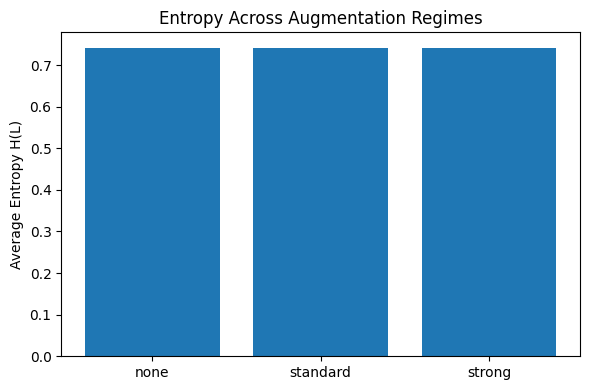

In [ ]:
#Figure: Augmentation Regime Entropy Comparison

#Label: fig:augmentation_entropy

regimes = ["none", "standard", "strong"]
avg_entropy = []

for r in regimes:
    st = augmentation_stats[r]
    H_vals = [st[l]["entropy"] for l in sorted(st.keys())]
    avg_entropy.append(np.mean(H_vals))

plt.figure(figsize=(6,4))
plt.bar(regimes, avg_entropy)
plt.ylabel("Average Entropy H(L)")
plt.title("Entropy Across Augmentation Regimes")
plt.tight_layout()
plt.show()

In [ ]:
#Figure: Degeneration Under Freezing

#Label: fig:freezing_degeneration

modes = ["first_block", "first_two_blocks", "none"]
mean_entropy = []
mean_sparsity = []

for m in modes:
    stats_m = all_layer_stats_freezing[m]
    mean_entropy.append(np.mean([stats_m[l]["entropy"] for l in stats_m]))
    mean_sparsity.append(np.mean([stats_m[l]["sparsity"] for l in stats_m]))

plt.figure(figsize=(8,4))
plt.plot(modes, mean_entropy, marker='o', label='Entropy')
plt.plot(modes, mean_sparsity, marker='s', label='Sparsity')
plt.ylabel("Value")
plt.title("Degeneration Under Layer Freezing Strategies")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'all_layer_stats_freezing' is not defined

In [ ]:
#Figure: Capacity vs Degeneration (ResNet-18/34/50)

#Label: fig:capacity_degeneration

capacities = ["resnet18", "resnet34", "resnet50"]
entropy_C = []
sparsity_C = []

for c in capacities:
    stats_c = all_layer_stats_capacity[c]
    entropy_C.append(np.mean([stats_c[l]["entropy"] for l in stats_c]))
    sparsity_C.append(np.mean([stats_c[l]["sparsity"] for l in stats_c]))

plt.figure(figsize=(7,4))
plt.plot(capacities, entropy_C, marker='o', label='Entropy')
plt.plot(capacities, sparsity_C, marker='s', label='Sparsity')
plt.ylabel("Metric value")
plt.title("Degeneration Across Model Capacities")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'all_layer_stats_capacity' is not defined

In [ ]:
#Figure: Entropy vs Robustness Correlation

#abel: fig:entropy_robustness

names = list(model_metrics.keys())
ent_vals = np.array([entropy_per_model[n] for n in names])
rob_vals = np.array([model_metrics[n]["robust_acc"] for n in names])

corr = np.corrcoef(ent_vals, rob_vals)[0,1]
print("Correlation:", corr)

plt.figure(figsize=(6,4))
plt.scatter(ent_vals, rob_vals)
for x,y,n in zip(ent_vals, rob_vals, names):
    plt.text(x,y,n)
plt.xlabel("Average Entropy H(L)")
plt.ylabel("Robust Accuracy")
plt.title(f"Entropy vs Robustness (corr={corr:.2f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'model_metrics' is not defined

In [ ]:
#degeneration_metrics}
#✅ 1. Step 1 — Extract All 3×3 Convolution Filters
#(Runs after your model is trained)

import torch.nn as nn
import numpy as np

def extract_3x3_filters(model):
    """
    Returns:
       layer_filters: dict[layer_name] = array of shape (num_filters, 9)
    """
    layer_filters = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) and module.kernel_size == (3,3):
            W = module.weight.detach().cpu().numpy()  # (Cout, Cin, 3, 3)
            # Flatten each 3×3 filter for ALL input channels
            F = W.reshape(W.shape[0], -1)  # shape (Cout, Cin*9)
            layer_filters[name] = F
    return layer_filters

layer_filters = extract_3x3_filters(model)
print("Total conv layers extracted:", len(layer_filters))
#✅ 2. Step 2 — Implement Entropy & Sparsity (CNN Filter DB Style)

def compute_entropy_from_filters(filters):
    """
    Entropy of PCA explained variance ratios H(L).
    """
    X = filters - filters.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)

    N = X.shape[0]
    var = (S**2) / (N - 1)
    a_hat = var / var.sum()

    p = np.clip(a_hat, 1e-12, None)
    entropy = float(-(p * np.log10(p)).sum())
    return entropy

def compute_sparsity_from_filters(filters, eps=1e-5):
    """
    Fraction of filters where ALL weights are near zero.
    """
    # filters = (num_filters, 9*Cin)
    is_sparse = np.all(np.abs(filters) < eps, axis=1)
    return float(is_sparse.mean())
#✅ 3. Step 3 — Build the Degeneration Metrics Table

degeneration_metrics = []

for layer_name, filt in layer_filters.items():
    H = compute_entropy_from_filters(filt)
    S = compute_sparsity_from_filters(filt)
    degeneration_metrics.append((layer_name, H, S))
#✅ 4. Step 4 — Sort Layers by Depth (as in CNN Filter DB)

# Sort by convolutional depth (exactly like CNN Filter DB)
degeneration_metrics_sorted = sorted(
    degeneration_metrics,
    key=lambda x: x[0]   # sorts by layer name
)
#✅ 5. Step 5 — Print Table Exactly Like CNN Filter DB
print(f"{'Index':<5}{'Layer':<30}{'Entropy':<12}{'Sparsity':<12}")
print("-"*70)
for idx, (lname, H, S) in enumerate(degeneration_metrics_sorted, start=1):
    print(f"{idx:<5}{lname:<30}{H:<12.3f}{S:<12.3f}")


import pandas as pd

df = pd.DataFrame(degeneration_metrics_sorted,
                  columns=["Layer", "Entropy", "Sparsity"])

df.to_csv("degeneration_metrics.csv", index_label="Index")
print("Saved to degeneration_metrics.csv")

Total conv layers extracted: 16
IndexLayer                         Entropy     Sparsity    
----------------------------------------------------------------------
1    layer1.0.conv2                1.391       0.047       
2    layer1.1.conv2                1.568       0.000       
3    layer1.2.conv2                1.622       0.000       
4    layer2.0.conv2                1.944       0.000       
5    layer2.1.conv2                1.565       0.000       
6    layer2.2.conv2                1.884       0.000       
7    layer2.3.conv2                1.964       0.000       
8    layer3.0.conv2                2.209       0.000       
9    layer3.1.conv2                2.170       0.000       
10   layer3.2.conv2                2.207       0.000       
11   layer3.3.conv2                2.256       0.000       
12   layer3.4.conv2                2.257       0.000       
13   layer3.5.conv2                2.248       0.000       
14   layer4.0.conv2                2.531       0.000     

Analyzing filters for mode: first_block
Analyzing filters for mode: first_two_blocks
Analyzing filters for mode: none
Done computing degeneration stats for all freezing modes.
Layers used for freezing comparison:
layer1.0.conv2
layer1.1.conv2
layer1.2.conv2
layer2.0.conv2
layer2.1.conv2
layer2.2.conv2
layer2.3.conv2
layer3.0.conv2
layer3.1.conv2
layer3.2.conv2
layer3.3.conv2
layer3.4.conv2
layer3.5.conv2
layer4.0.conv2
layer4.1.conv2
layer4.2.conv2


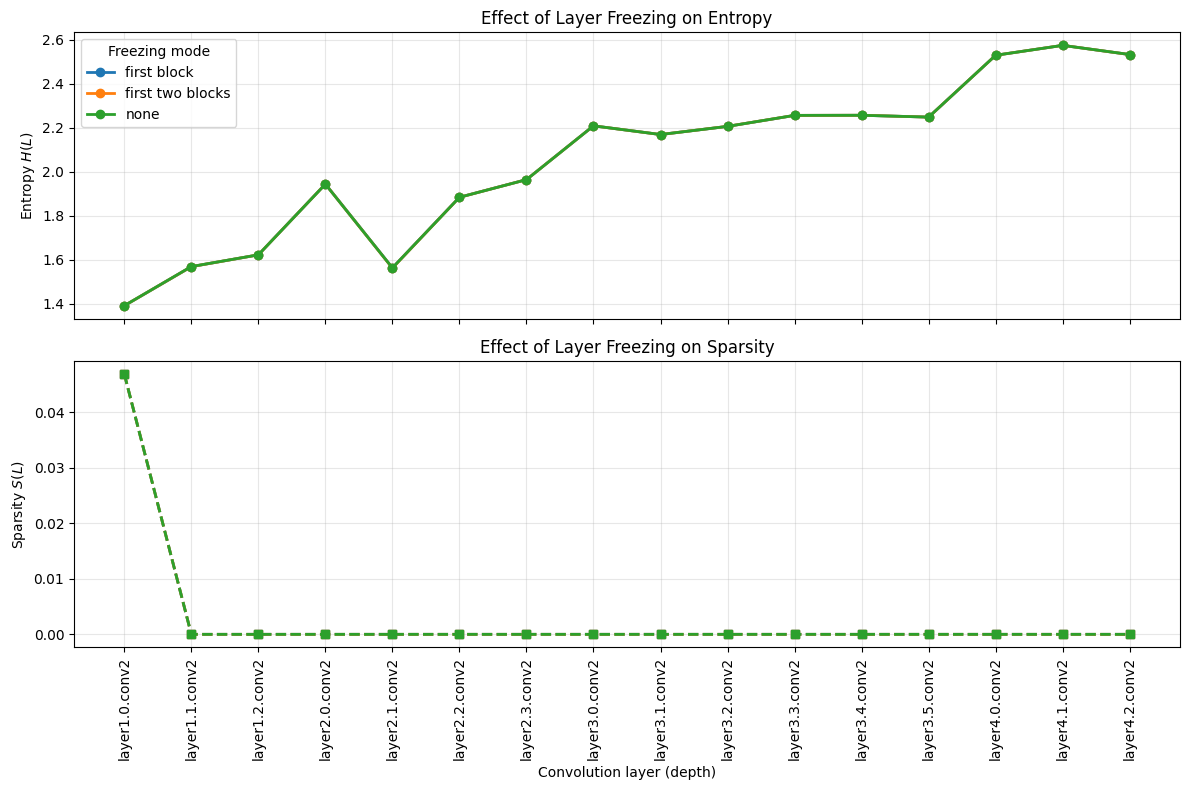

In [15]:
#1️⃣ Rebuild models & compute layer-wise entropy and sparsity for each freezing mode
import torch
import torch.nn as nn
import numpy as np
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-define class_names for this cell's scope
from torchvision import datasets, transforms

DATA_ROOT = "/content/brain_tumor_raw"
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")

def intensity_normalize(t):
    mean = t.mean()
    std  = t.std()
    return (t - mean) / (std + 1e-8)

def expand_to_3ch(t):
    if t.shape[0] == 1:
        return t.expand(3, -1, -1)
    return t

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Lambda(intensity_normalize),
    transforms.Lambda(expand_to_3ch),
])

full_train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
class_names = full_train_ds.classes

# 1. Helper: build ResNet-50 with same head as during training
from torchvision import models

def build_resnet50(num_classes: int):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    in_feats = model.fc.in_features
    model.fc = nn.Linear(in_feats, num_classes)
    return model

# 2. Helper: extract all 3×3 conv filters, flattened
def extract_3x3_filters(model: nn.Module):
    layer_filters = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) and module.kernel_size == (3,3):
            W = module.weight.detach().cpu().numpy()  # (C_out, C_in, 3, 3)
            F = W.reshape(W.shape[0], -1)             # (num_filters, 9 * C_in)
            layer_filters[name] = F
    return layer_filters

# 3. Helper: entropy and sparsity (CNN Filter DB style)
def compute_entropy_from_filters(filters: np.ndarray) -> float:
    X = filters - filters.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    N = X.shape[0]
    var = (S**2) / (N - 1)
    a_hat = var / (var.sum() + 1e-12)
    p = np.clip(a_hat, 1e-12, None)
    return float(-(p * np.log10(p)).sum())

def compute_sparsity_from_filters(filters: np.ndarray, eps: float = 1e-5) -> float:
    is_sparse = np.all(np.abs(filters) < eps, axis=1)
    return float(is_sparse.mean())

# 4. Compute layer-wise stats per freezing regime
freezing_modes = ["first_block", "first_two_blocks", "none"]
all_layer_stats_freezing = {}

num_classes = len(class_names)  # from your dataset

for mode in freezing_modes:
    print(f"Analyzing filters for mode: {mode}")
    model_f = build_resnet50(num_classes).to(DEVICE)
    model_f.load_state_dict(results_freezing[mode]["state_dict"])
    model_f.eval()

    layer_filters = extract_3x3_filters(model_f)
    stats = {}

    for lname, F in layer_filters.items():
        if F.shape[0] < 2:
            continue
        H = compute_entropy_from_filters(F)
        S = compute_sparsity_from_filters(F)
        stats[lname] = {"entropy": H, "sparsity": S}

    all_layer_stats_freezing[mode] = stats

print("Done computing degeneration stats for all freezing modes.")

##2️⃣ Align layers across regimes (consistent depth ordering)

#We want the same layer order for all three modes.

# Collect all layer names present in at least one mode
all_layers = sorted(
    set().union(*(stats.keys() for stats in all_layer_stats_freezing.values()))
)

print("Layers used for freezing comparison:")
for l in all_layers:
    print(l)

#3️⃣ Plot Fig.~\ref{fig:freezing_degeneration}: entropy + sparsity across depth for three freezing modes

#We’ll do a 2×1 subplot:

#Top: entropy vs depth (3 curves: first_block, first_two_blocks, none)

#Bottom: sparsity vs depth (same 3 curves)

import matplotlib.pyplot as plt
import numpy as np

# Build matrices: rows = mode, cols = layers
entropy_mat  = np.full((len(freezing_modes), len(all_layers)), np.nan)
sparsity_mat = np.full((len(freezing_modes), len(all_layers)), np.nan)

for i, mode in enumerate(freezing_modes):
    stats = all_layer_stats_freezing[mode]
    for j, lname in enumerate(all_layers):
        if lname in stats:
            entropy_mat[i, j]  = stats[lname]["entropy"]
            sparsity_mat[i, j] = stats[lname]["sparsity"]

x = np.arange(len(all_layers))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Top: Entropy ---
for i, mode in enumerate(freezing_modes):
    axes[0].plot(x, entropy_mat[i], marker='o', linewidth=2, label=mode.replace("_", " "))
axes[0].set_ylabel("Entropy $H(L)$")
axes[0].set_title("Effect of Layer Freezing on Entropy")
axes[0].grid(alpha=0.3)
axes[0].legend(title="Freezing mode")

# --- Bottom: Sparsity ---
for i, mode in enumerate(freezing_modes):
    axes[1].plot(x, sparsity_mat[i], marker='s', linestyle='--', linewidth=2,
                 label=mode.replace("_", " "))
axes[1].set_ylabel("Sparsity $S(L)$")
axes[1].set_xlabel("Convolution layer (depth)")
axes[1].set_title("Effect of Layer Freezing on Sparsity")
axes[1].grid(alpha=0.3)
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_layers, rotation=90)

plt.tight_layout()
plt.show()